## Setup

In [1]:
import logging
import sys

sys.path.append('../')

from protac_degradation_predictor.data.datasets import MolPoiE3CellDataset

# Setup logging level
logging.basicConfig(level=logging.INFO)

/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from lightning_uq_box.viz_utils import (
    plot_calibration_uq_toolbox,
    plot_predictions_regression,
    plot_toy_regression_data,
    plot_training_metrics,
)
from lightning_uq_box.uq_methods.loss_functions import DERLoss
from lightning_uq_box.uq_methods.deep_evidential_regression import DERLayer

INFO:root:Asdfghjkl backend not available since the old asdfghjkl dependency is not installed. If you want to use it, run: pip install git+https://git@github.com/wiseodd/asdl@asdfghjkl


In [3]:
import pytorch_lightning as pl
import torch

pl.seed_everything(42)
torch.set_default_dtype(torch.float32)

Seed set to 42


## Prepare Data

In [65]:
from datasets import load_dataset

# Load the dataset from HuggingFace Hub
dataset = load_dataset("ailab-bio/PROTAC-Degradation-Predictor-Dataset")

dataset

DatasetDict({
    train: Dataset({
        features: ['Smiles', 'POI Sequence', 'E3 Ligase Sequence', 'Cell Type', 'Uniprot', 'POI Cluster', 'E3 Ligase', 'Dmax (%) (DC50/Dmax)', 'pDC50 (DC50/Dmax)', 'pIC50 (Cellular activities, IC50)', 'pIC50 (Protac to Target, IC50)'],
        num_rows: 5248
    })
    validation: Dataset({
        features: ['Smiles', 'POI Sequence', 'E3 Ligase Sequence', 'Cell Type', 'Uniprot', 'POI Cluster', 'E3 Ligase', 'Dmax (%) (DC50/Dmax)', 'pDC50 (DC50/Dmax)', 'pIC50 (Cellular activities, IC50)', 'pIC50 (Protac to Target, IC50)'],
        num_rows: 542
    })
    test: Dataset({
        features: ['Smiles', 'POI Sequence', 'E3 Ligase Sequence', 'Cell Type', 'Uniprot', 'POI Cluster', 'E3 Ligase', 'Dmax (%) (DC50/Dmax)', 'pDC50 (DC50/Dmax)', 'pIC50 (Cellular activities, IC50)', 'pIC50 (Protac to Target, IC50)'],
        num_rows: 921
    })
})

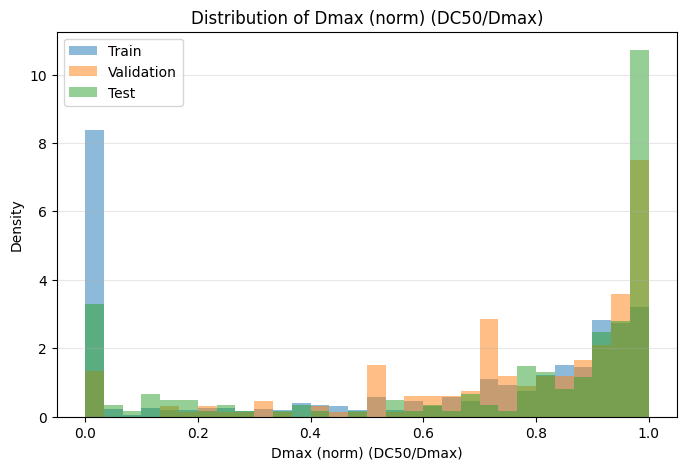

In [66]:
from protac_degradation_predictor.data.utils import dmax_forward
import pandas as pd

train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

for df in [train_df, val_df, test_df]:
    df['Dmax (norm) (DC50/Dmax)'] = df['Dmax (%) (DC50/Dmax)'].apply(dmax_forward)
    df['Dmax (%) (DC50/Dmax)'] = df['Dmax (%) (DC50/Dmax)'] / 100
    # df['Dmax (norm) (DC50/Dmax)'] = df['Dmax (norm) (DC50/Dmax)'].apply(lambda x: x / 10)
    # # Scale other labels by a factor of 10
    # df["pDC50 (DC50/Dmax)"] = df["pDC50 (DC50/Dmax)"].apply(lambda x: x / 10)
    # df["pIC50 (Cellular activities, IC50)"] = df["pIC50 (Cellular activities, IC50)"].apply(lambda x: x / 10)
    # df["pIC50 (Protac to Target, IC50)"] = df["pIC50 (Protac to Target, IC50)"].apply(lambda x: x / 10)

label_columns = [
    "Dmax (%) (DC50/Dmax)",
    "pDC50 (DC50/Dmax)",
    "pIC50 (Cellular activities, IC50)",
    "pIC50 (Protac to Target, IC50)",
]

# Plot the distributions of the Dmax (norm) label
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train_df[label_columns[0]], bins=30, alpha=0.5, label='Train', color='C0', density=True)
plt.hist(val_df[label_columns[0]], bins=30, alpha=0.5, label='Validation', color='C1', density=True)
plt.hist(test_df[label_columns[0]], bins=30, alpha=0.5, label='Test', color='C2', density=True)
plt.xlabel('Dmax (norm) (DC50/Dmax)')
plt.ylabel('Density')
plt.title('Distribution of Dmax (norm) (DC50/Dmax)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [67]:
# Setup logging level
logging.basicConfig(level=logging.DEBUG)

datasets = {}
for split, df in zip(["train", "val", "test"], [train_df, val_df, test_df]):
    print('-' * 80)
    print(f"Processing {split} dataset with {len(df)} samples.")
    print('-' * 80)
    datasets[split] = MolPoiE3CellDataset(
        df=df,
        mol_column="Smiles",
        poi_column="POI Sequence",
        e3_column="E3 Ligase Sequence",
        cell_column="Cell Type",
        label_columns=label_columns,
        mol_embeddings_kwargs={
            # "embeddings_type": "fingerprint", 
            # "radius": 3,
            # "fp_size": 2048,
            "embeddings_type": "transformer",
            "pretrained_model": "ailab-bio/PROTAC-Splitter-Encoder",
            "load_from_cache": True,
        },
        protein_embeddings_kwargs={
            # "embeddings_type": "amino_acid_count",
            # "count_vect_kwargs": {
            #     "ngram_range": (1, 3),
            #     "analyzer": "char_wb",
            #     "vocabulary": list("ARNDCQEGHILKMFPSTWYVBZX*"),
            #     "lowercase": False,
            # }
            "embeddings_type": "esm",
            "batch_size": 2,
            "load_from_cache": True,
        },
        cell_embeddings_kwargs={
            # "embeddings_type": "one_hot",
            # "onehot_enc_kwargs": {},
            "embeddings_type": "sentence_transformer",
            "load_from_cache": True,
        },
        # imputer="iterative" if split == "train" else None,
        # imputer_kwargs={} if split == "train" else None,
        save_embeddings_to_cache=True, #  if split == "train" else False,
    )

# Setup logging level
logging.basicConfig(level=logging.INFO)

--------------------------------------------------------------------------------
Processing train dataset with 5248 samples.
--------------------------------------------------------------------------------


INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz


--------------------------------------------------------------------------------
Processing val dataset with 542 samples.
--------------------------------------------------------------------------------


INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz


--------------------------------------------------------------------------------
Processing test dataset with 921 samples.
--------------------------------------------------------------------------------


INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz


In [68]:
from torch.utils.data import DataLoader

dl = DataLoader(datasets["train"], batch_size=16, shuffle=True)
next(iter(dl))

{'mol': tensor([[ 1.0960e+02, -4.2652e+01, -5.1190e+01,  ..., -6.9816e+01,
           1.0771e+01,  1.5344e+02],
         [ 1.0436e+02, -2.7411e+01, -3.6753e+01,  ..., -1.7993e+01,
           8.1984e+01,  4.0233e+01],
         [ 9.1693e+01, -4.3671e+01, -5.7454e+01,  ..., -9.3870e+00,
           8.8405e+01,  5.7499e+01],
         ...,
         [ 2.0578e+02, -2.6456e+01, -1.4030e+02,  ..., -7.6036e+01,
           4.3063e+01,  1.8131e+02],
         [ 6.9285e+01,  1.8770e-01, -3.7887e+01,  ..., -3.7411e+01,
           4.5535e+01,  3.5328e+01],
         [ 2.6637e+02,  2.4314e+01, -9.2904e+00,  ..., -6.4647e+01,
           1.2145e+02,  1.2040e+02]]),
 'poi': tensor([[ 1.2661e+01, -1.4062e+02,  5.1249e+01,  ...,  2.9717e+02,
          -1.0770e+02,  1.2322e+00],
         [-2.7362e+01, -1.0319e+02,  3.2041e+01,  ...,  8.1869e+01,
          -7.3619e+00,  1.7429e+01],
         [-1.8230e+01, -8.3635e+01,  4.5443e+01,  ...,  9.0068e+01,
          -7.0121e+00,  3.4695e+01],
         ...,
         [ 

In [69]:
import pytorch_lightning as pl
from torch.utils.data import DataLoader

class PROTACDataModule(pl.LightningDataModule):
    def __init__(
        self,
        datasets_dict,
        batch_size: int = 32,
        num_workers: int = 0,
        pin_memory: bool = True,
    ):
        super().__init__()
        self.datasets_dict = datasets_dict
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.pin_memory = pin_memory
        
    def prepare_data(self):
        # Data is already prepared in the datasets
        pass
    
    def setup(self, stage=None):
        # Datasets are already created and passed in
        self.train_dataset = self.datasets_dict["train"]
        self.val_dataset = self.datasets_dict["val"] 
        self.test_dataset = self.datasets_dict["test"]
    
    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
        )
    
    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
        )

# Create the data module using existing datasets
protac_dm = PROTACDataModule(
    datasets_dict=datasets,
    batch_size=32,
    num_workers=0,
    pin_memory=True,
)

# Test the data module
protac_dm.setup()
train_loader = protac_dm.train_dataloader()
batch = next(iter(train_loader))

print("Batch keys:", list(batch.keys()))
for key, value in batch.items():
    if hasattr(value, 'shape'):
        print(f"{key}: {value.shape} - {value.dtype}")
    else:
        print(f"{key}: {type(value)}")

Batch keys: ['mol', 'poi', 'e3', 'cell', 'Dmax (%) (DC50/Dmax)', 'pDC50 (DC50/Dmax)', 'pIC50 (Cellular activities, IC50)', 'pIC50 (Protac to Target, IC50)']
mol: torch.Size([32, 768]) - torch.float32
poi: torch.Size([32, 320]) - torch.float32
e3: torch.Size([32, 320]) - torch.float32
cell: torch.Size([32, 768]) - torch.float32
Dmax (%) (DC50/Dmax): torch.Size([32]) - torch.float64
pDC50 (DC50/Dmax): torch.Size([32]) - torch.float64
pIC50 (Cellular activities, IC50): torch.Size([32]) - torch.float64
pIC50 (Protac to Target, IC50): torch.Size([32]) - torch.float64


/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


## Define Model

In [70]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional

class GPTStyleFeedForward(nn.Module):
    """
    Pre-LN feed-forward block used in decoder-only Transformers (Radford et al., 2018/GPT family).

    Structure (for input X ∈ R^{BxTxd_model}):
        Y = X + Dropout( W2 * φ( W1 * LN(X) ) )
    where φ is GELU, and W1,W2 are linear (affine) maps with optional bias.

    Parameters
    ----------
    d_model : int
        Hidden size of the model.
    d_ff : Optional[int]
        Inner width of the MLP. Defaults to 4 * d_model if None.
    dropout : float
        Dropout probability applied after the second linear.
    bias : bool
        Whether to use bias terms in the two linear layers. In GPT-style models this is True. 
        (See HF GPT-2 `Conv1D` layers, which include `bias`.) 
    eps : float
        Epsilon for LayerNorm stability.

    Notes
    -----
    * This follows the *pre-norm* residual layout used in GPT-1/2: LayerNorm → MLP → residual add.
    * Activation is GELU, as in GPT-2.
    * Expected input shape is (batch, seq, d_model); the module is position-wise.
    """
    def __init__(
        self,
        d_model: int,
        d_ff: Optional[int] = None,
        dropout: float = 0.0,
        bias: bool = True,
        eps: float = 1e-5,
    ) -> None:
        super().__init__()
        inner = 4 * d_model if d_ff is None else d_ff

        # Pre-norm
        self.ln = nn.LayerNorm(d_model, eps=eps)

        # Two affine projections (bias enabled by default, matching GPT practice)
        self.fc1 = nn.Linear(d_model, inner, bias=bias)
        self.fc2 = nn.Linear(inner, d_model, bias=bias)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args
        ----
        x : Tensor of shape (B, T, d_model)

        Returns
        -------
        Tensor of shape (B, T, d_model)
        """
        # Pre-norm residual block
        h = self.ln(x)
        h = F.gelu(self.fc1(h))       # position-wise nonlinearity
        h = self.fc2(h)
        h = self.dropout(h)
        return x + h                   # residual add

class InputScaler(nn.Module):
    """
    Input scaling layer that applies a linear transformation to the input features.

    Parameters
    ----------
    in_features : int
        Number of input features.
    out_features : int
        Number of output features.
    bias : bool, optional
        Whether to include a bias term in the linear transformation. Default is True.
    norm : bool, optional
        Whether to apply Layer Normalization before the linear transformation. Default is False.
    """
    def __init__(
            self,
            in_features: int,
            out_features: int,
            bias: bool = True,
            norm: bool = False,
    ):
        super().__init__()
        self.norm = None
        if norm:
            self.norm = nn.LayerNorm(in_features)
        self.linear = nn.Linear(in_features, out_features, bias=bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.norm is not None:
            x = self.norm(x)
        x = self.linear(x)
        # Divide by the square root of the output dimension to maintain variance
        # This is a common practice in Transformer models to stabilize training
        return F.softmax(x / (self.linear.out_features ** 0.5), dim=-1)

In [71]:
from typing import List, Dict
from torch import nn
import torch

class Backbone(nn.Module):
    """
    Backbone network for feature embedding and trunk processing.
    """
    def __init__(
            self,
            feature_dims: Dict[str, int],
            hidden_dim: int = 128,
            trunk_size: int = 1,
            dropout: float = 0.1,
            norm: bool = False,
    ):
        super().__init__()
        self.input_scaler = nn.ModuleDict({
            k: InputScaler(d, hidden_dim, norm=norm) for k, d in feature_dims.items()
        })
        self.trunk = nn.Sequential(
            *[GPTStyleFeedForward(hidden_dim, hidden_dim, dropout) for _ in range(trunk_size)]
        )

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        embedded_features = []
        for k in self.input_scaler.keys():
            if k in batch:
                embedded_features.append(self.input_scaler[k](batch[k]))
            else:
                raise KeyError(f"Key '{k}' not found in the input batch.")
        # Stack along a new dimension and sum to combine features
        x = torch.stack(embedded_features, dim=-1)  # (batch_size, hidden_dim, n_features)
        x = x.sum(dim=-1)  # (batch_size, hidden_dim)
        x = self.trunk(x)
        return x

class RegressionModel(nn.Module):
    """
    Regression model with backbone, linear head, and DER layer.
    """
    def __init__(
            self,
            feature_dims: Dict[str, int],
            n_targets: int = 1,
            trunk_size: int = 1,
            hidden_dim: int = 128,
            dropout: float = 0.1,
            norm: bool = False,
    ):
        super().__init__()
        self.backbone = Backbone(
            feature_dims=feature_dims,
            hidden_dim=hidden_dim,
            trunk_size=trunk_size,
            dropout=dropout,
            norm=norm,
        )
        self.lin_head = nn.Linear(hidden_dim, 4 * n_targets, bias=False)
        self.der_layer = DERLayer()

    def forward(self, batch: Dict[str, torch.Tensor], return_embeddings: bool = False) -> torch.Tensor:
        embedding = self.backbone(batch)
        x = self.lin_head(embedding)
        x = x.view(x.size(0), 4, -1)
        x = self.der_layer(x)
        if return_embeddings:
            return x, embedding
        return x

# Example usage
feature_dims = {
    'feature_0': 256,
    'feature_1': 64,
    'feature_2': 64,
    'feature_3': 128,
}
model = RegressionModel(
    feature_dims=feature_dims,
    n_targets=3,
    trunk_size=2,
    hidden_dim=128,
    dropout=0.1
)
# Print the model architecture
print(model)
# Example input batch
batch = {
    'feature_0': torch.randn(8, 256),
    'feature_1': torch.randn(8, 64),
    'feature_2': torch.randn(8, 64),
    'feature_3': torch.randn(8, 128),
}
# Forward pass
output = model(batch)
print("Output shape:", output.shape)  # Should be (8, 4, 3) for 8 samples, 4 outputs per target label
# Output shape: (8, 4, 3)

# Run it through a DER layer
print("DER output shape:", output.shape)  # Should be (8, 4, 3) for 8 samples, 4 outputs per target label
# Output shape: (8, 4, 3)

# Test with the DERLoss
der_loss = DERLoss(coeff=0.2)
loss = der_loss(output, torch.randn(8, 1, 3))
print("Loss:", loss.item())  # Should print a scalar loss value

RegressionModel(
  (backbone): Backbone(
    (input_scaler): ModuleDict(
      (feature_0): InputScaler(
        (linear): Linear(in_features=256, out_features=128, bias=True)
      )
      (feature_1): InputScaler(
        (linear): Linear(in_features=64, out_features=128, bias=True)
      )
      (feature_2): InputScaler(
        (linear): Linear(in_features=64, out_features=128, bias=True)
      )
      (feature_3): InputScaler(
        (linear): Linear(in_features=128, out_features=128, bias=True)
      )
    )
    (trunk): Sequential(
      (0): GPTStyleFeedForward(
        (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (fc1): Linear(in_features=128, out_features=128, bias=True)
        (fc2): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (1): GPTStyleFeedForward(
        (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (fc1): Linear(in_features=128, out_features=128, bias

In [104]:
from lightning.pytorch.loggers import CSVLogger
from lightning_uq_box.uq_methods.utils import default_regression_metrics

class DERModel(pl.LightningModule):

    def __init__(
            self,
            label_names: List[str] = None,
            label_weights: Dict[str, float] = None,
            der_loss_coeffs: Dict[str, float] = None,
            default_der_loss_coeff: float = 0.01,
            learning_rate: float = 1e-3,
            **model_kwargs: Dict[str, int],
    ):
        super().__init__()
        self.save_hyperparameters()

        self.learning_rate = learning_rate
        self.model = RegressionModel(**model_kwargs)

        self.label_names = label_names if label_names is not None else [f"label_{i}" for i in range(model_kwargs.get("n_targets", 1))]

        # Create explicit mapping from label names to output indices
        self.label_to_idx = {name: i for i, name in enumerate(self.label_names)}

        # Set up label weights - default to equal weights if not provided
        if label_weights is None:
            self.label_weights = {name: 1.0 for name in self.label_names}
        else:
            # Ensure all labels have weights, default missing ones to 1.0
            self.label_weights = {name: label_weights.get(name, 1.0) for name in self.label_names}
        
        # Normalize weights so they sum to the number of labels (maintains scale)
        total_weight = sum(self.label_weights.values())
        if total_weight > 0:
            self.label_weights = {name: weight * len(self.label_names) / total_weight 
                                 for name, weight in self.label_weights.items()}

        # Create individual DER loss functions for each label
        self.loss_functions = nn.ModuleDict()
        for label_name in self.label_names:
            coeff = der_loss_coeffs.get(label_name, default_der_loss_coeff) if der_loss_coeffs else default_der_loss_coeff
            self.loss_functions[label_name] = DERLoss(coeff)

        # Add metrics for logging
        self.metrics = {}
        for label in self.label_names:
            for stage in ["train", "val", "test"]:
                metric_id = f"{stage}_{label}"
                self.metrics[metric_id] = default_regression_metrics(f"{metric_id}_")
        # NOTE: Metrics are nn.Module, so they must be registered accordingly
        self.metrics = nn.ModuleDict(self.metrics)

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model(batch)

    def _prepare_labels_tensor(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        """
        Prepare labels tensor in the correct order for the loss function.
        
        Args:
            batch: Input batch containing labels
            
        Returns:
            torch.Tensor of shape (batch_size, 1, n_targets)
        """
        # Use self.label_to_idx to ensure correct ordering
        labels_list = [batch[label] for label in self.label_names]
        labels = torch.stack(labels_list, dim=-1)  # Shape: (batch_size, n_targets)
        return labels.unsqueeze(1)  # Shape: (batch_size, 1, n_targets)

    def _filter_nan_samples(self, preds: torch.Tensor, targets: torch.Tensor) -> tuple:
        """
        Filter out samples where targets contain NaN values.
        
        Args:
            preds: Predictions tensor
            targets: Target tensor
            
        Returns:
            Tuple of (filtered_preds, filtered_targets)
        """
        valid_mask = ~torch.isnan(targets)
        if valid_mask.sum() == 0:
            # If all samples are NaN, return empty tensors
            return preds[:0], targets[:0]
        
        return preds[valid_mask], targets[valid_mask]

    def _compute_weighted_loss(self, outputs: torch.Tensor, labels: torch.Tensor) -> tuple:
        """
        Compute weighted loss for each label and return the weighted average.
        
        Args:
            outputs: Model outputs of shape (batch_size, 4, n_targets)
            labels: Ground truth labels of shape (batch_size, 1, n_targets)
            
        Returns:
            Tuple of (weighted_loss, per_label_losses, valid_samples_per_label)
        """
        per_label_losses = []
        valid_samples_per_label = {}
        
        for label_name in self.label_names:
            idx = self.label_to_idx[label_name]
            
            # Extract outputs and labels for this specific label
            label_outputs = outputs[:, :, idx:idx+1]  # Shape: (batch_size, 4, 1)
            label_targets = labels[:, :, idx:idx+1]   # Shape: (batch_size, 1, 1)
            
            # Flatten for NaN filtering
            label_targets_flat = label_targets.squeeze(-1).squeeze(-1)  # Shape: (batch_size,)
            
            # Filter out NaN samples
            valid_mask = ~torch.isnan(label_targets_flat)
            n_valid = valid_mask.sum().item()
            valid_samples_per_label[label_name] = n_valid
            
            if n_valid == 0:
                # If all samples are NaN for this label, set loss to 0
                label_loss = torch.tensor(0.0, device=outputs.device, requires_grad=True)
                self.log(f"nan_warning_{label_name}", 1.0, on_step=False, on_epoch=True)
            else:
                # Filter valid samples
                valid_label_outputs = label_outputs[valid_mask]  # Shape: (n_valid, 4, 1)
                valid_label_targets = label_targets[valid_mask]  # Shape: (n_valid, 1, 1)
                
                # Compute loss for this label using its specific loss function
                label_loss = self.loss_functions[label_name](valid_label_outputs, valid_label_targets)
            
            per_label_losses.append(label_loss)
        
        # Stack losses and apply weights
        per_label_losses = torch.stack(per_label_losses)  # Shape: (n_targets,)
        
        # Apply weights - only to labels that have valid samples
        weighted_losses = []
        total_weight = 0.0
        
        for i, label_name in enumerate(self.label_names):
            if valid_samples_per_label[label_name] > 0:
                weight = self.label_weights[label_name]
                weighted_losses.append(per_label_losses[i] * weight)
                total_weight += weight
        
        if len(weighted_losses) == 0:
            # All labels have NaN - return zero loss
            weighted_loss = torch.tensor(0.0, device=outputs.device, requires_grad=True)
        else:
            # Compute weighted average
            weighted_loss = torch.stack(weighted_losses).sum() / max(total_weight, 1e-8)
        
        return weighted_loss, per_label_losses, valid_samples_per_label

    def _process_batch(self, batch: Dict[str, torch.Tensor], stage: str):
        """
        Helper method to process a batch for training, validation, or testing.
        Reduces code duplication and ensures consistent logic.
        """
        outputs = self(batch)
        labels = self._prepare_labels_tensor(batch)
        
        # Compute weighted loss and per-label losses
        loss, per_label_losses, valid_samples_count = self._compute_weighted_loss(outputs, labels)
        
        # Log overall loss
        self.log(f"{stage}_loss", loss, on_step=(stage=="train"), on_epoch=True, prog_bar=True)
        
        # Log per-label losses and valid sample counts
        for i, label_name in enumerate(self.label_names):
            self.log(f"{stage}_loss_{label_name}", per_label_losses[i], 
                    on_step=(stage=="train"), on_epoch=True, prog_bar=False)
            self.log(f"{stage}_valid_samples_{label_name}", valid_samples_count[label_name], 
                    on_step=False, on_epoch=True, prog_bar=False)

        # Update metrics for each label using explicit mapping (with NaN filtering)
        for label_name, output_idx in self.label_to_idx.items():
            preds = outputs[:, 0, output_idx]  # Get predictions for this label
            target = batch[label_name]  # Get target for this label
            
            # Filter out NaN values for metrics computation
            filtered_preds, filtered_target = self._filter_nan_samples(preds, target)
            
            if len(filtered_target) > 0:  # Only compute metrics if we have valid samples
                metrics_key = f"{stage}_{label_name}"
                if stage == "train":
                    # For training, compute and log metrics immediately
                    scores = self.metrics[metrics_key](filtered_preds, filtered_target)
                    self.log_dict(scores)
                else:
                    # For validation/test, just update metrics
                    self.metrics[metrics_key].update(filtered_preds, filtered_target)
        
        return loss

    def training_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        return self._process_batch(batch, "train")

    def validation_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        return self._process_batch(batch, "val")

    def on_validation_epoch_end(self):
        for label_name in self.label_names:
            metrics_key = f"val_{label_name}"
            metrics = self.metrics[metrics_key].compute()
            self.log_dict(metrics)
            self.metrics[metrics_key].reset()

    def test_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        return self._process_batch(batch, "test")

    def on_test_epoch_end(self):
        for label_name in self.label_names:
            metrics_key = f"test_{label_name}"
            metrics = self.metrics[metrics_key].compute()
            self.log_dict(metrics)
            self.metrics[metrics_key].reset()

    def predict_step(
        self, X: torch.Tensor, batch_idx: int = 0, dataloader_idx: int = 0
    ) -> Dict[str, torch.Tensor]:
        """Prediction Step Deep Evidential Regression.

        Args:
            X: prediction batch of shape [batch_size x input_dims]
            batch_idx: the index of this batch
            dataloader_idx: the index of the dataloader

        Returns:
            dictionary with predictions and uncertainty measures
        """
        with torch.no_grad():
            pred = self.forward(X)  # [batch_size x 4 x othe_dims]

        gamma, nu, alpha, beta = (
            pred[:, 0:1, ...],
            pred[:, 1:2, ...],
            pred[:, 2:3, ...],
            pred[:, 3:4, ...],
        )

        epistemic_uct = self.compute_epistemic_uct(nu)
        aleatoric_uct = self.compute_aleatoric_uct(beta, alpha, nu)
        pred_uct = epistemic_uct + aleatoric_uct

        results = {
            "pred": gamma.squeeze(1),
            "pred_uct": pred_uct.squeeze(1),
            "aleatoric_uct": aleatoric_uct.squeeze(1),
            "epistemic_uct": epistemic_uct.squeeze(1),
            "out": pred,
        }
    
        for label_name, idx in self.label_to_idx.items():
            results[f"pred_{label_name}"] = gamma[:, 0, idx]
            results[f"pred_uct_{label_name}"] = pred_uct[:, 0, idx]
            results[f"aleatoric_uct_{label_name}"] = aleatoric_uct[:, 0, idx]
            results[f"epistemic_uct_{label_name}"] = epistemic_uct[:, 0, idx]

        return results

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate)
        lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer=optimizer,
            mode='min',
            factor=0.1,
            patience=0,
        )
        # if self.trainer.max_epochs:
        #     total_iters = self.trainer.max_epochs
        # elif self.trainer.max_steps:
        #     total_iters = self.trainer.max_steps
        # else:
        #     total_iters = 20
        # lr_scheduler = optim.lr_scheduler.LinearLR(
        #     optimizer=optimizer,
        #     total_iters=total_iters,
        # )
        return {
            'optimizer': optimizer,
            'lr_scheduler': lr_scheduler,
            'interval': 'step',  # or 'epoch'
            'frequency': 1,
            'monitor': 'val_loss',
        }

    def compute_aleatoric_uct(self, beta: torch.Tensor, alpha: torch.Tensor, nu: torch.Tensor) -> torch.Tensor:
        """Compute the aleatoric uncertainty for DER model.

        Equation 10 of the paper

        Args:
            beta: beta output DER model
            alpha: alpha output DER model
            nu: nu output DER model

        Returns:
            Aleatoric Uncertainty
        """
        return torch.sqrt(torch.div(beta * (1 + nu), alpha * nu))

    def compute_epistemic_uct(self, nu: torch.Tensor) -> torch.Tensor:
        """Compute the aleatoric uncertainty for DER model.

        Equation 10: of the paper

        Args:
            nu: nu output DER model
        Returns:
            Epistemic Uncertainty
        """
        return torch.reciprocal(torch.sqrt(nu))
    
    def extract_embeddings(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        """
        Extract embeddings from the model for the given batch.
        
        Args:
            batch: Input batch containing features
            
        Returns:
            Tensor of shape (batch_size, hidden_dim)
        """
        with torch.no_grad():
            _, embeddings = self.model.eval()(batch, return_embeddings=True)
        return embeddings


n_targets = len(label_columns)
trunk_size = 3
hidden_dim = 128
dropout = 0.8
norm = False # Default: False
learning_rate = 1e-4
feature_dims = datasets["train"].shapes()

print("Feature dimensions:", feature_dims)

# Define custom weights for each label loss term
label_weights = {
    "Dmax (%) (DC50/Dmax)": 3.0,
    "pDC50 (DC50/Dmax)": 1.0,
    "pIC50 (Cellular activities, IC50)": 1.0,
    "pIC50 (Protac to Target, IC50)": 1.0,
}

# Define different DER loss coefficients (regularization) for each label
der_loss_coeffs = {
    "Dmax (%) (DC50/Dmax)": 0.3,
    "pDC50 (DC50/Dmax)": 0.2,
    "pIC50 (Cellular activities, IC50)": 0.2,
    "pIC50 (Protac to Target, IC50)": 0.2,
}

der_model = DERModel(
    label_names=label_columns,
    label_weights=label_weights,
    der_loss_coeffs=der_loss_coeffs,
    feature_dims=feature_dims,
    n_targets=n_targets,
    trunk_size=trunk_size,
    hidden_dim=hidden_dim,
    dropout=dropout,
    norm=norm,
    learning_rate=learning_rate,
).float()
print(der_model)

Feature dimensions: {'mol': 768, 'poi': 320, 'e3': 320, 'cell': 768}
DERModel(
  (model): RegressionModel(
    (backbone): Backbone(
      (input_scaler): ModuleDict(
        (mol): InputScaler(
          (linear): Linear(in_features=768, out_features=128, bias=True)
        )
        (poi): InputScaler(
          (linear): Linear(in_features=320, out_features=128, bias=True)
        )
        (e3): InputScaler(
          (linear): Linear(in_features=320, out_features=128, bias=True)
        )
        (cell): InputScaler(
          (linear): Linear(in_features=768, out_features=128, bias=True)
        )
      )
      (trunk): Sequential(
        (0): GPTStyleFeedForward(
          (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear(in_features=128, out_features=128, bias=True)
          (fc2): Linear(in_features=128, out_features=128, bias=True)
          (dropout): Dropout(p=0.8, inplace=False)
        )
        (1): GPTStyleFeedForward(
          (ln):

## Training

In [105]:
# Revert logging level to INFO to reduce verbosity
logging.getLogger().setLevel(logging.INFO)

In [106]:
import tempfile

my_temp_dir = tempfile.mkdtemp()

In [107]:
protac_dm = PROTACDataModule(
    datasets_dict=datasets,
    batch_size=128,
    num_workers=0,
    pin_memory=True,
)

# Test the data module
protac_dm.setup()

logger = CSVLogger(my_temp_dir)
trainer = pl.Trainer(
    # fast_dev_run=True,
    max_epochs=20, # number of epochs we want to train
    logger=logger, # log training metrics for later evaluation
    log_every_n_steps=1,
    enable_checkpointing=False,
    enable_progress_bar=True,
    default_root_dir=my_temp_dir,
    num_sanity_val_steps=1, # Run one validation step before training to check the model and data
    val_check_interval=0.5, # Validate every 50% of the training steps
    gradient_clip_val=1.0, # Clip gradients to avoid exploding gradients
    precision='32-true',
    accelerator='cpu',
)
der_model = der_model.float()
trainer.fit(der_model, datamodule=protac_dm)

INFO: GPU available: True (mps), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (mps), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/core/optimizer.py:378: Found unsupported keys in the optimizer configuration: {'frequency', 'interval'}

  | Name           | Type            | Params | Mode 
------------------------------------------------

/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.
/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 

Epoch 19: 100%|██████████| 41/41 [00:03<00:00, 11.20it/s, v_num=0, train_loss_step=2.900, val_loss=2.560, train_loss_epoch=2.830]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 41/41 [00:03<00:00, 11.17it/s, v_num=0, train_loss_step=2.900, val_loss=2.560, train_loss_epoch=2.830]


## Evaluation

--------------------
Plotting train metrics
--------------------
Label 1: Dmax (%) (DC50/Dmax)


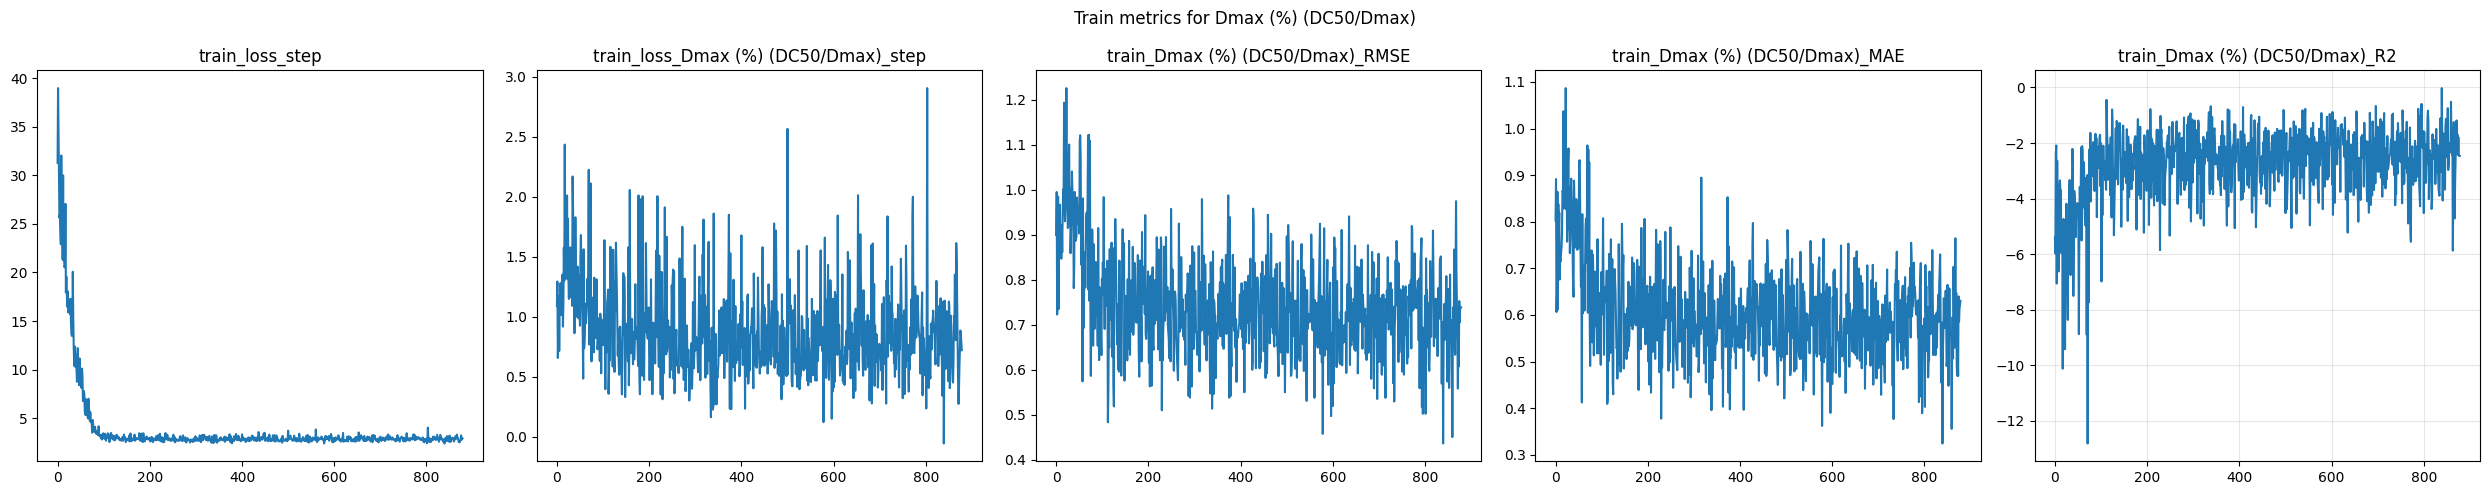

Label 2: pDC50 (DC50/Dmax)


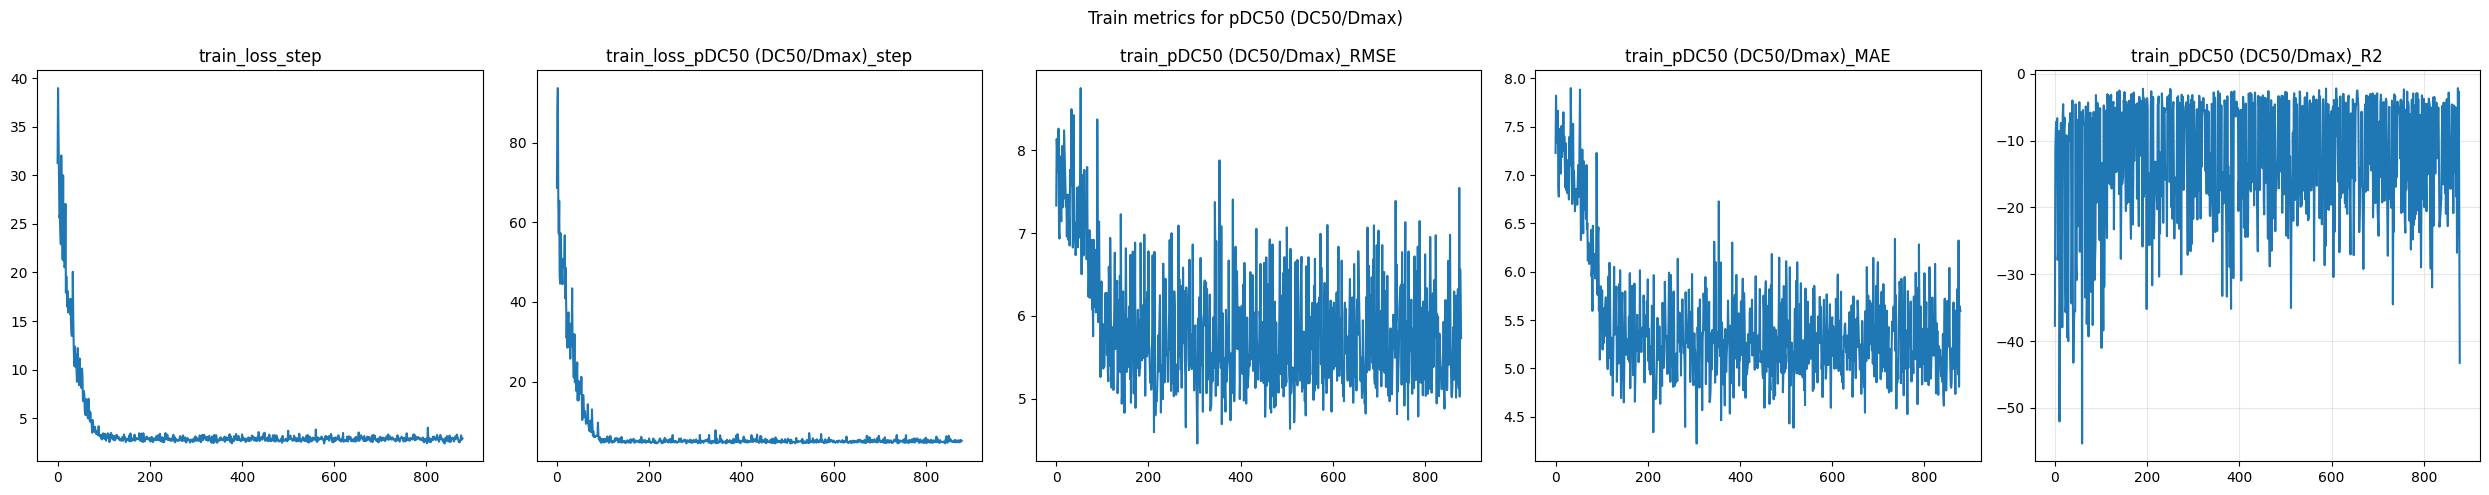

Label 3: pIC50 (Cellular activities, IC50)


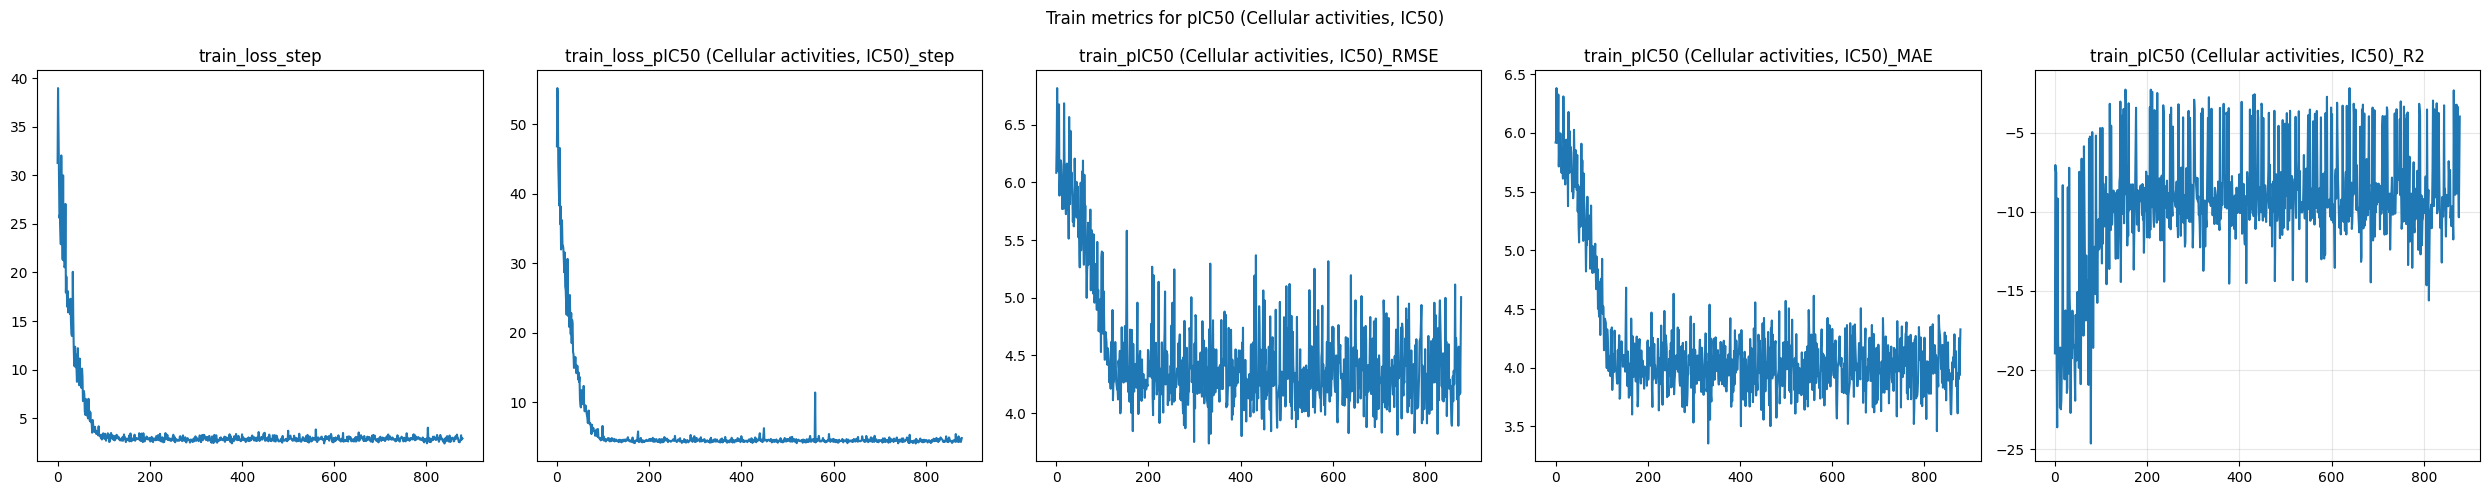

Label 4: pIC50 (Protac to Target, IC50)


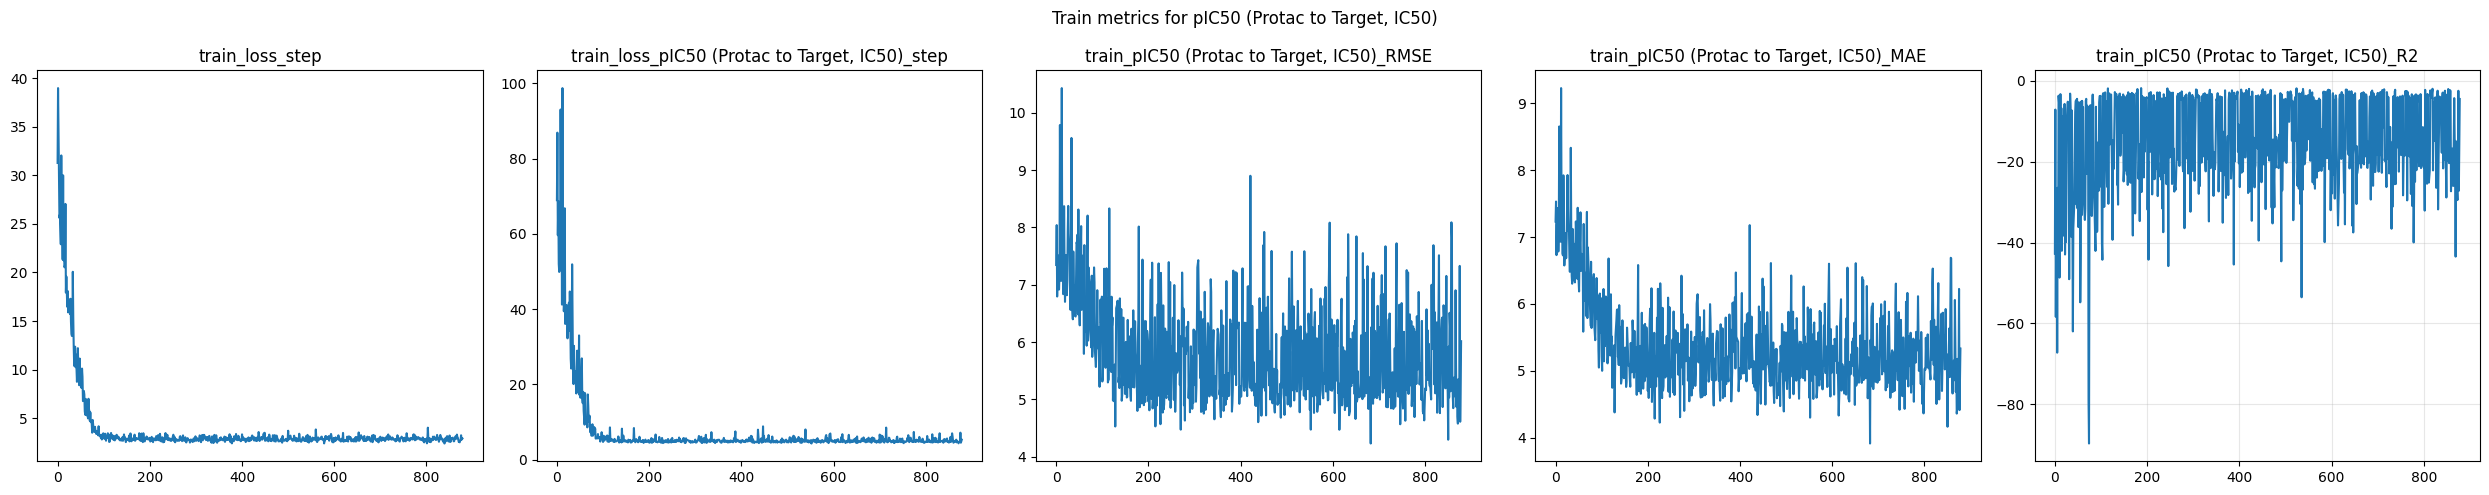

--------------------
Plotting val metrics
--------------------
Label 1: Dmax (%) (DC50/Dmax)


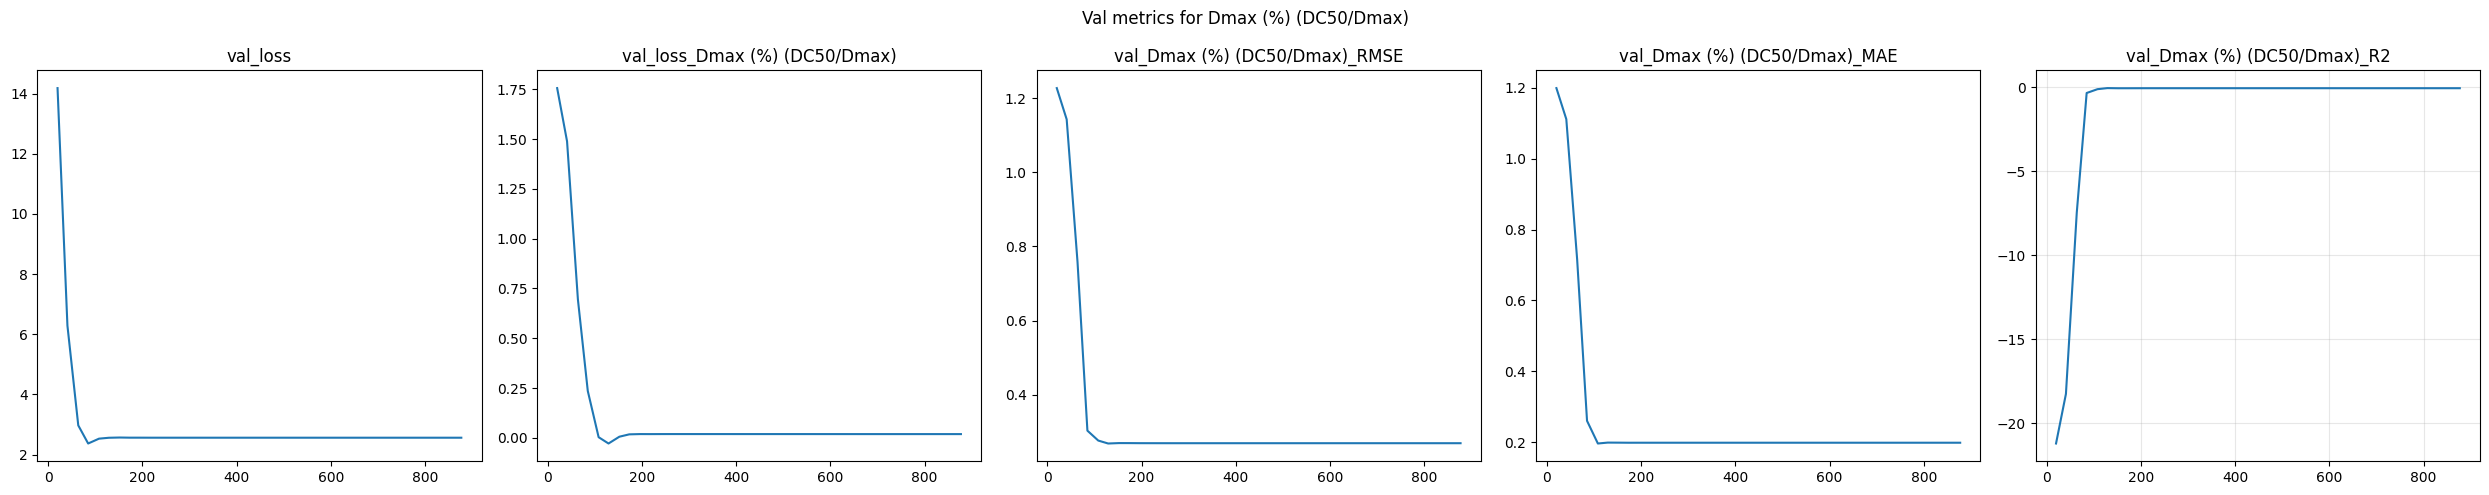

Label 2: pDC50 (DC50/Dmax)


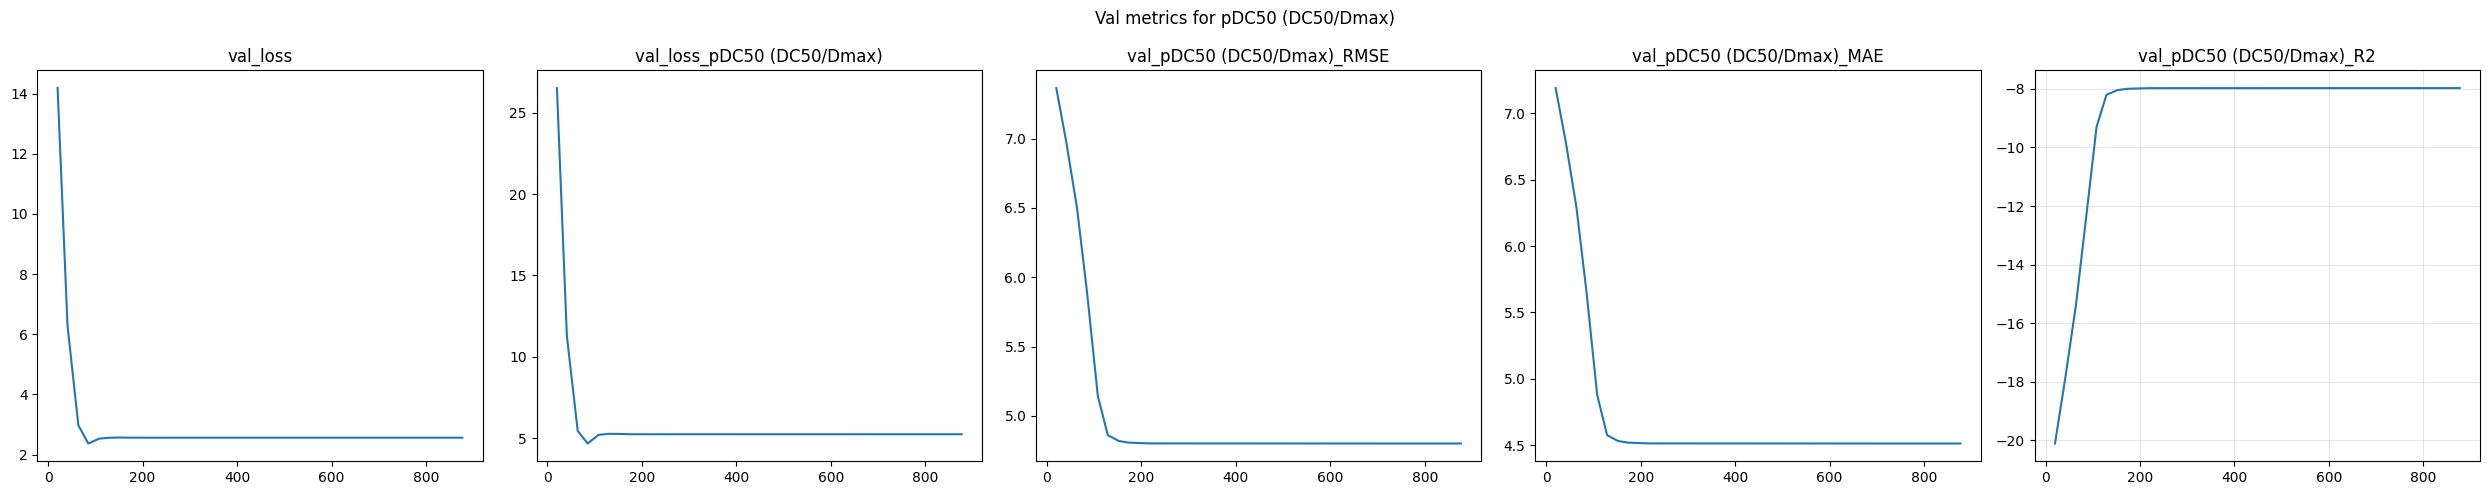

Label 3: pIC50 (Cellular activities, IC50)


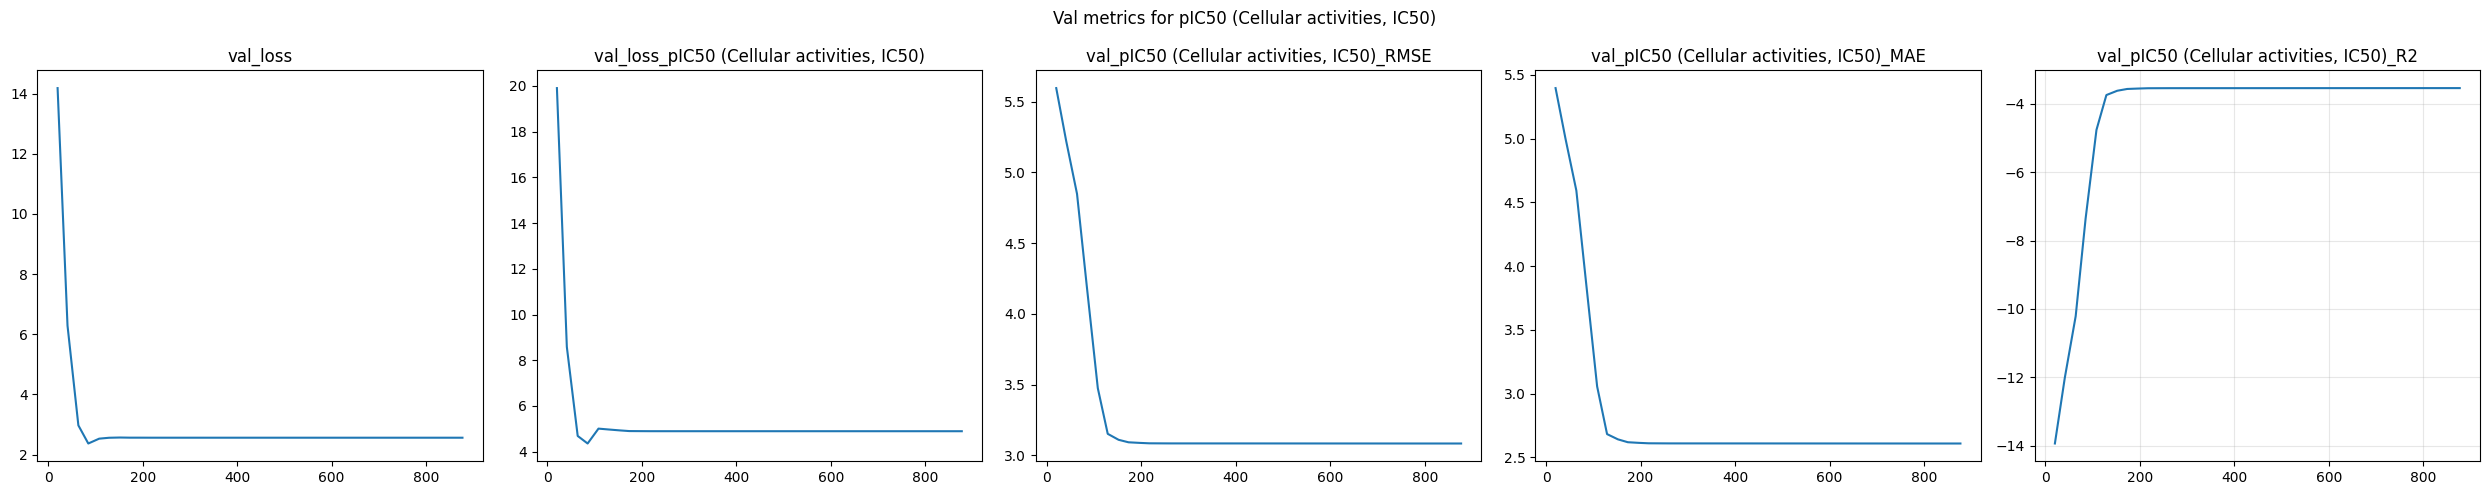

Label 4: pIC50 (Protac to Target, IC50)


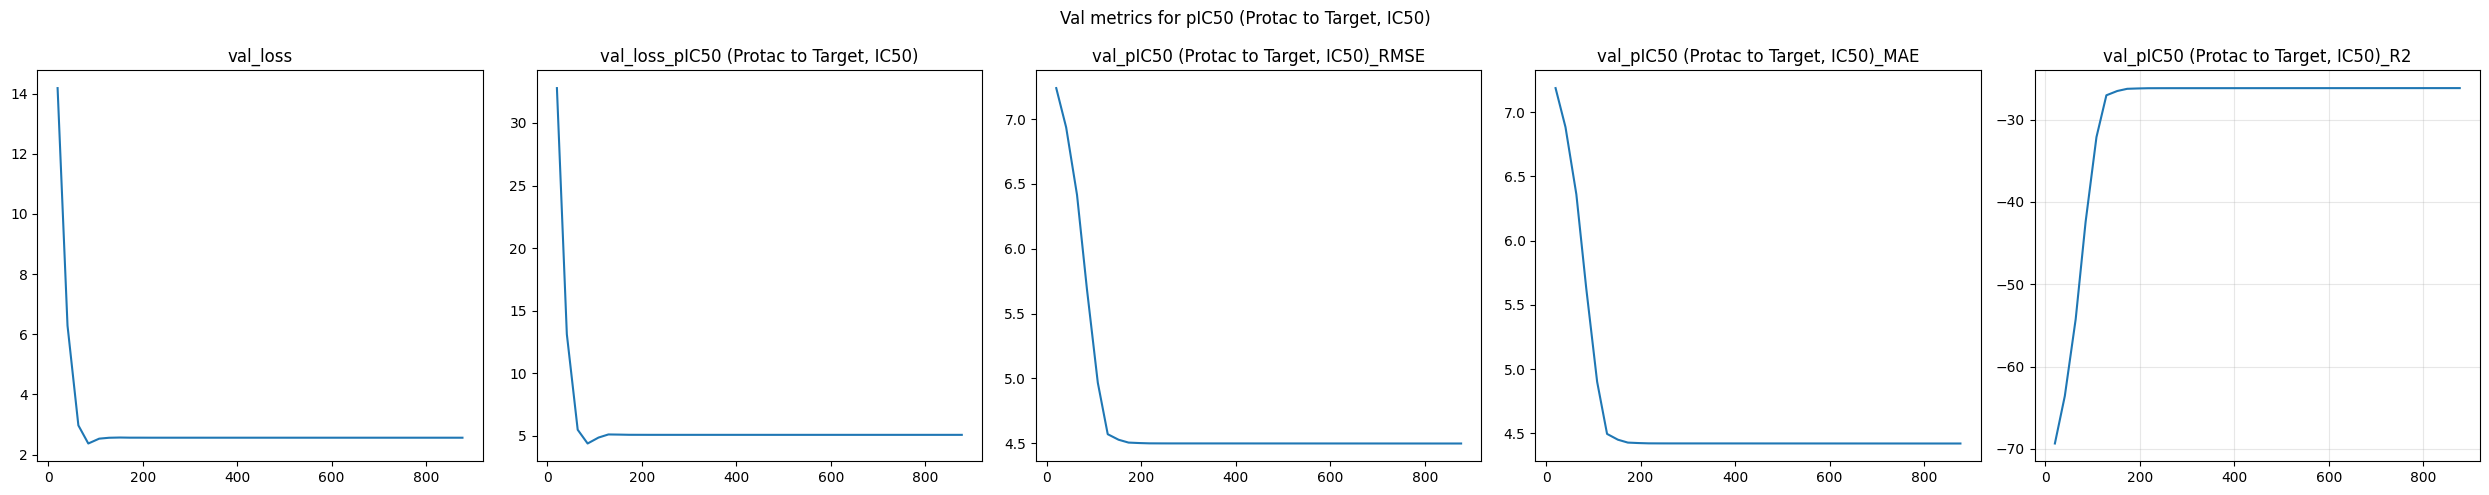

In [108]:
import os
import matplotlib.pyplot as plt

for stage in ["train", "val"]:
    print("-" * 20)
    print(f"Plotting {stage} metrics")
    print("-" * 20)
    for i, label_name in enumerate(label_columns):
        print(f"Label {i + 1}: {label_name}")
        metrics_to_plot = [
            f"{stage}_loss" + ("_step" if stage == "train" else ""),
            f"{stage}_loss_{label_name}" + ("_step" if stage == "train" else ""),
            f"{stage}_{label_name}_RMSE",
            f"{stage}_{label_name}_MAE",
            f"{stage}_{label_name}_R2",
        ]
        fig = plot_training_metrics(
            os.path.join(my_temp_dir,"lightning_logs"), metrics_to_plot,
        )
        # Plot fig
        fig.suptitle(f"{stage.title()} metrics for {label_name}")
        plt.grid(axis='both', alpha=0.3)
        plt.tight_layout()
        plt.show()

/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.
/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting DataLoader 0: 100%|██████████| 8/8 [00:00<00:00, 30.94it/s] 
Predictions shape: torch.Size([128, 4])
Stacked predictions shape: torch.Size([921, 4])
Labels shape: torch.Size([921])
--------------------------------------------------------------------------------
Plotting test predictions for label 1: Dmax (%) (DC50/Dmax)
--------------------------------------------------------------------------------
Number of valid test samples for Dmax (%) (DC50/Dmax): 182
Number of predictions: 921
Number of uncertainties: 921
Number of valid samples after NaN removal: 182
Number of predictions after NaN removal: 182
Number of uncertainties after NaN removal: 182


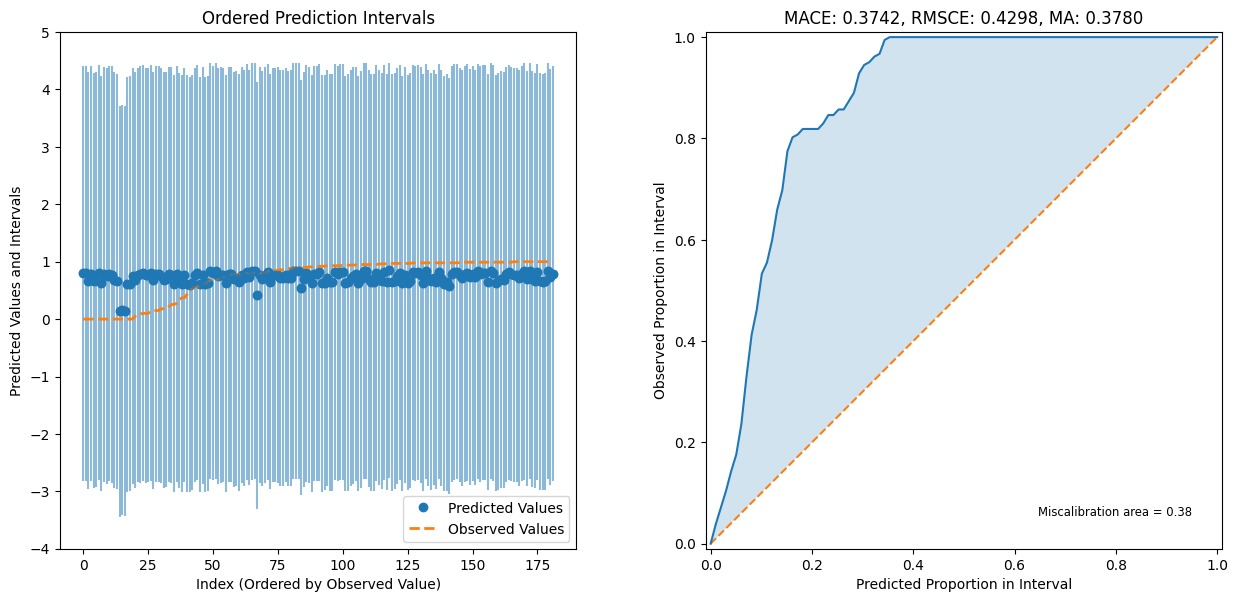

--------------------------------------------------------------------------------
Plotting test predictions for label 2: pDC50 (DC50/Dmax)
--------------------------------------------------------------------------------
Number of valid test samples for pDC50 (DC50/Dmax): 263
Number of predictions: 921
Number of uncertainties: 921
Number of valid samples after NaN removal: 263
Number of predictions after NaN removal: 263
Number of uncertainties after NaN removal: 263


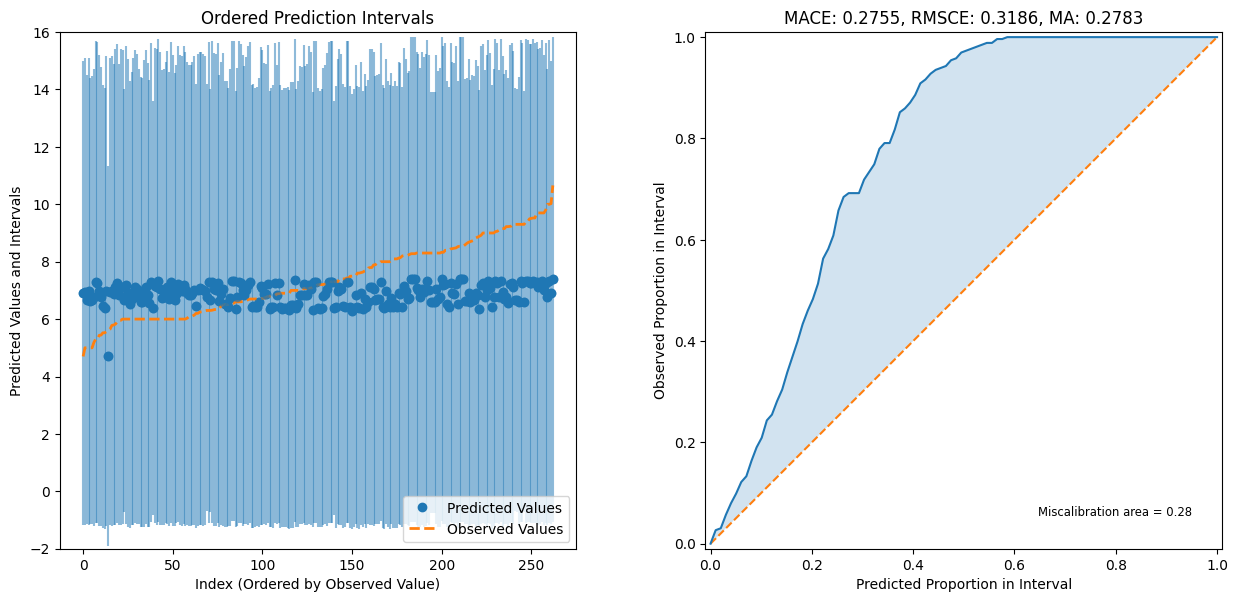

--------------------------------------------------------------------------------
Plotting test predictions for label 3: pIC50 (Cellular activities, IC50)
--------------------------------------------------------------------------------
Number of valid test samples for pIC50 (Cellular activities, IC50): 587
Number of predictions: 921
Number of uncertainties: 921
Number of valid samples after NaN removal: 587
Number of predictions after NaN removal: 587
Number of uncertainties after NaN removal: 587


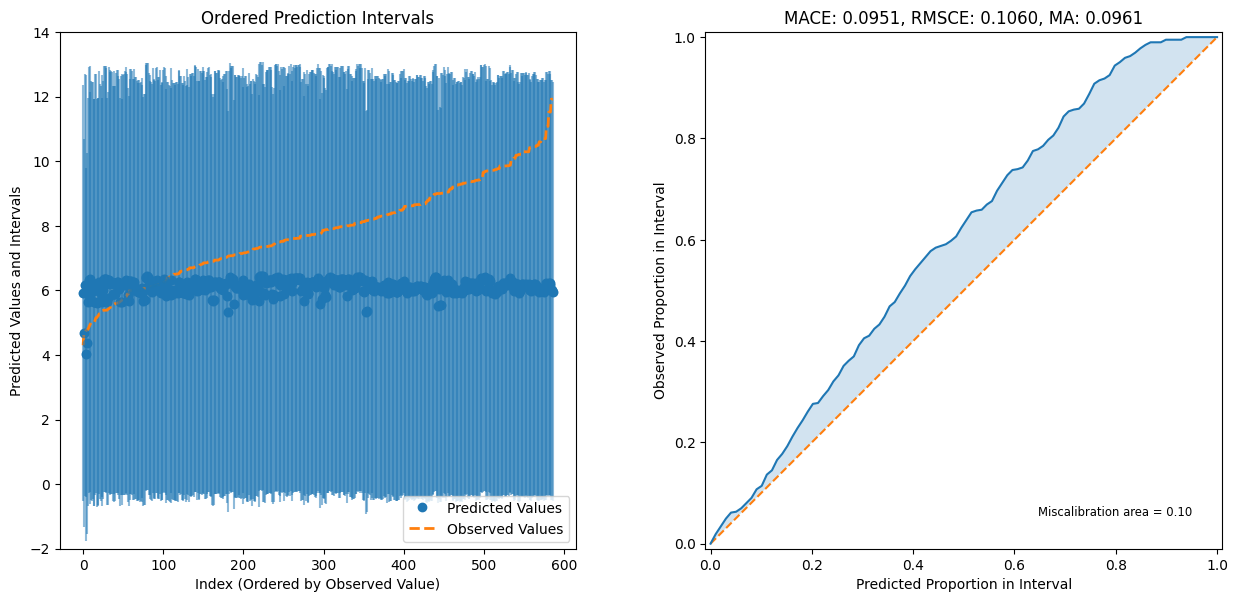

--------------------------------------------------------------------------------
Plotting test predictions for label 4: pIC50 (Protac to Target, IC50)
--------------------------------------------------------------------------------
Number of valid test samples for pIC50 (Protac to Target, IC50): 157
Number of predictions: 921
Number of uncertainties: 921
Number of valid samples after NaN removal: 157
Number of predictions after NaN removal: 157
Number of uncertainties after NaN removal: 157


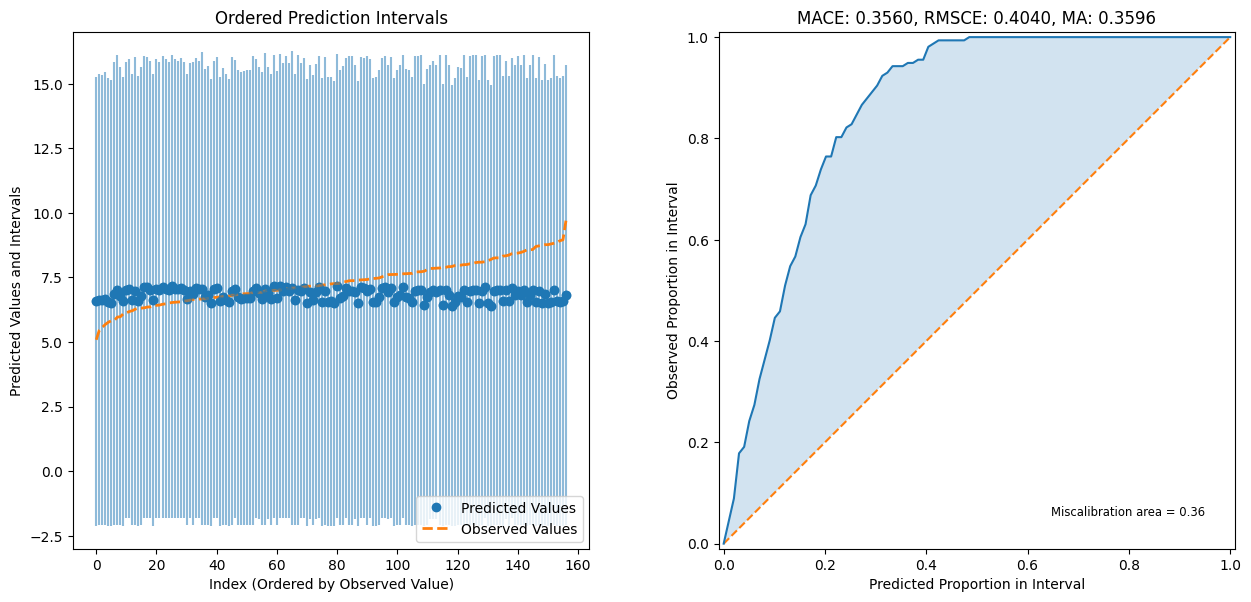

In [102]:
import uncertainty_toolbox as uct
import numpy as np

def plot_predictions_regression(
        y_pred: np.ndarray,
        pred_std: np.ndarray,
        Y_test: np.ndarray,
        x_test: Optional[np.ndarray] = None,
        skip_xy_plot: bool = True,
) -> plt.Figure:
    """Plot calibration from uq_toolbox.

    Taken from https://github.com/uncertainty-toolbox/uncertainty-toolbox/
    blob/main/examples/viz_readme_figures.py.

    Args:
      y_pred: model mean predictions
      pred_std: predicted standard deviations
      Y_test: test data targets
      x_test: test data inputs
    """
    y_pred = y_pred.squeeze()
    pred_std = pred_std.squeeze()
    Y_test = Y_test.squeeze()
    if x_test is not None:
        x_test = x_test.squeeze()
    # n_subset = min(50, y_pred.shape[0])
    n_subset = y_pred.shape[0]
    mace = uct.mean_absolute_calibration_error(y_pred, pred_std, Y_test)
    ma = uct.miscalibration_area(y_pred, pred_std, Y_test)
    rmsce = uct.root_mean_squared_calibration_error(y_pred, pred_std, Y_test)

    if skip_xy_plot:
        fig, axs = plt.subplots(1, 2, figsize=(15, 8))

        # Make ordered intervals plot
        axs[0] = uct.plot_intervals_ordered(
            y_pred, pred_std, Y_test, n_subset=n_subset, ax=axs[0]
        )

        # Make calibration plot
        axs[1] = uct.plot_calibration(y_pred, pred_std, Y_test, ax=axs[1])

        # Adjust subplots spacing
        fig.subplots_adjust(wspace=0.25)

        axs[1].set_title(f"MACE: {mace:.4f}, RMSCE: {rmsce:.4f}, MA: {ma:.4f}")

        return fig
    else:
        fig, axs = plt.subplots(1, 3)

        # Make xy plot
        axs[0] = uct.plot_xy(y_pred, pred_std, Y_test, x_test, ax=axs[0])

        # Make ordered intervals plot
        axs[1] = uct.plot_intervals_ordered(
            y_pred, pred_std, Y_test, n_subset=n_subset, ax=axs[1]
        )

        # Make calibration plot
        axs[2] = uct.plot_calibration(y_pred, pred_std, Y_test, ax=axs[2])

        # Adjust subplots spacing
        fig.subplots_adjust(wspace=0.25)

        axs[2].set_title(f"MACE: {mace:.4f}, RMSCE: {rmsce:.4f}, MA: {ma:.4f}")

        return fig

preds = trainer.predict(der_model, dataloaders=protac_dm.test_dataloader())
# Stack predictions from all batches
print(f"Predictions shape: {preds[0]['pred'].shape}")  # Should be (batch_size, n_targets)
preds = {k: torch.cat([p[k] for p in preds], dim=0) for k in preds[0].keys()}
print(f"Stacked predictions shape: {preds['pred'].shape}")  # Should be (n_samples, n_targets)

# Assemble the labels from the batches in the test dataloader
labels = {}
for batch in protac_dm.test_dataloader():
    for i, label_name in enumerate(label_columns):
        if label_name not in labels:
            labels[label_name] = batch[label_name]
        else:
            labels[label_name] = torch.cat((labels[label_name], batch[label_name]), dim=0)
print(f"Labels shape: {labels[label_columns[0]].shape}")  # Should be (n_samples,)

for i, label_name in enumerate(label_columns):
    print("-" * 80)
    print(f"Plotting test predictions for label {i + 1}: {label_name}")
    print("-" * 80)
    
    # Remove NaN values corresponding to missing labels
    y_test = labels[label_name].cpu().numpy()
    mask = ~np.isnan(y_test)
    y_test = y_test[mask]
    print(f"Number of valid test samples for {label_name}: {len(y_test)}")
    print(f"Number of predictions: {preds[f'pred_{label_name}'].shape[0]}")
    print(f"Number of uncertainties: {preds[f'pred_uct_{label_name}'].shape[0]}")
    print(f"Number of valid samples after NaN removal: {mask.sum()}")
    preds[f"pred_{label_name}"] = preds[f"pred_{label_name}"][mask]
    preds[f"pred_uct_{label_name}"] = preds[f"pred_uct_{label_name}"][mask]
    print(f"Number of predictions after NaN removal: {preds[f'pred_{label_name}'].shape[0]}")
    print(f"Number of uncertainties after NaN removal: {preds[f'pred_uct_{label_name}'].shape[0]}")
    
    fig = plot_predictions_regression(
        y_pred=preds[f"pred_{label_name}"].cpu().numpy(),
        pred_std=preds[f"pred_uct_{label_name}"].cpu().numpy(),
        Y_test=y_test,
        x_test=None,
    )
    plt.show()
    plt.close()

In [103]:
import pandas as pd

val_metrics = trainer.validate(der_model, dataloaders=protac_dm.val_dataloader(), verbose=0)[0]
test_metrics = trainer.test(der_model, dataloaders=protac_dm.test_dataloader(), verbose=0)[0]

# Make a dataframe to summarize the val and test metrics
print()
summary_data = []
for elem in sorted(list(val_metrics.keys())):
    elem = elem.replace("val_", "").replace("test_", "")
    summary_data.append({
        "metric": elem,
        "val": val_metrics.get(f"val_{elem}"),
        "test": test_metrics.get(f"test_{elem}"),
    })
    
summary_df = pd.DataFrame(summary_data).round(2)
print(summary_df.to_markdown(index=False))

/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


Validation DataLoader 0: 100%|██████████| 5/5 [00:00<00:00, 31.27it/s] 

/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.



Testing DataLoader 0: 100%|██████████| 8/8 [00:00<00:00, 25.42it/s] 

| metric                                          |    val |   test |
|:------------------------------------------------|-------:|-------:|
| nan_warning_pIC50 (Protac to Target, IC50)      | nan    | nan    |
| Dmax (%) (DC50/Dmax)_MAE                        |   0.2  |   0.28 |
| Dmax (%) (DC50/Dmax)_R2                         |   0.19 |   0.04 |
| Dmax (%) (DC50/Dmax)_RMSE                       |   0.23 |   0.35 |
| loss                                            |   0.32 |   0.62 |
| loss_Dmax (%) (DC50/Dmax)                       |  -1.39 |  -1.06 |
| loss_pDC50 (DC50/Dmax)                          |   2.28 |   2.13 |
| loss_pIC50 (Cellular activities, IC50)          |   1.78 |   2.68 |
| loss_pIC50 (Protac to Target, IC50)             |   2.04 |   2.1  |
| pDC50 (DC50/Dmax)_MAE                           |   1.42 |   1.15 |
| pDC50 (DC50/Dmax)_R2                            |  -0    |  -0.14 |
| pDC50 (DC50/Dmax)

## Extract Embeddings

In [79]:
protac_dm = PROTACDataModule(
    datasets_dict=datasets,
    batch_size=16,
    num_workers=0,
    pin_memory=True,
)

protac_dm.setup()
batch = next(iter(protac_dm.train_dataloader()))
extracted_embeddings = der_model.extract_embeddings(batch)
print("Extracted embeddings shape:", extracted_embeddings.shape, extracted_embeddings.mean())  # Should be (batch_size, hidden_dim)

Extracted embeddings shape: torch.Size([16, 512]) tensor(-0.0003)


---

## Legacy Code

In [9]:
from sklearn.datasets import make_regression
import numpy as np


n_samples = 2000
feature_dims = [256, 64, 64, 128]
n_targets = 3
random_state = 42
label_noise = 0.1

rng = np.random.default_rng(random_state)

# Generate features with different dimensions
features = [make_regression(n_samples=n_samples, n_features=dim, noise=0.1)[0] for dim in feature_dims]

# Concatenate all features horizontally
X = np.hstack(features)

# Generate real-valued labels
y = rng.normal(loc=0, scale=1, size=(n_samples, n_targets))
y += rng.uniform(-label_noise, label_noise, size=(n_samples, n_targets))

# Skew the labels to be non-negative
min_label = np.min(y)
if min_label < 0:
    y -= min_label + rng.uniform(0.1, 0.5)  # Shift to ensure non-negativity

# Zero-inflate one of the labels randomly
if n_targets > 0:
    zero_inflate_idx = rng.integers(0, n_targets)
    # Set a fraction of the label to zero
    zero_fraction = rng.uniform(0.10, 0.15)  # 5% to 10% zero
    num_zeros = int(n_samples * zero_fraction)
    zero_indices = rng.choice(n_samples, size=num_zeros, replace=False)
    y[zero_indices, zero_inflate_idx] = 0.0  # Set to zero
    
    # scale them between 0 and 1
    y[:, zero_inflate_idx] = (y[:, zero_inflate_idx] - np.min(y[:, zero_inflate_idx])) / (np.max(y[:, zero_inflate_idx]) - np.min(y[:, zero_inflate_idx]))

# Print the shapes of the generated data
print(f'Features shape: {X.shape}')
print(f'Targets shape: {y.shape}')

Features shape: (2000, 512)
Targets shape: (2000, 3)


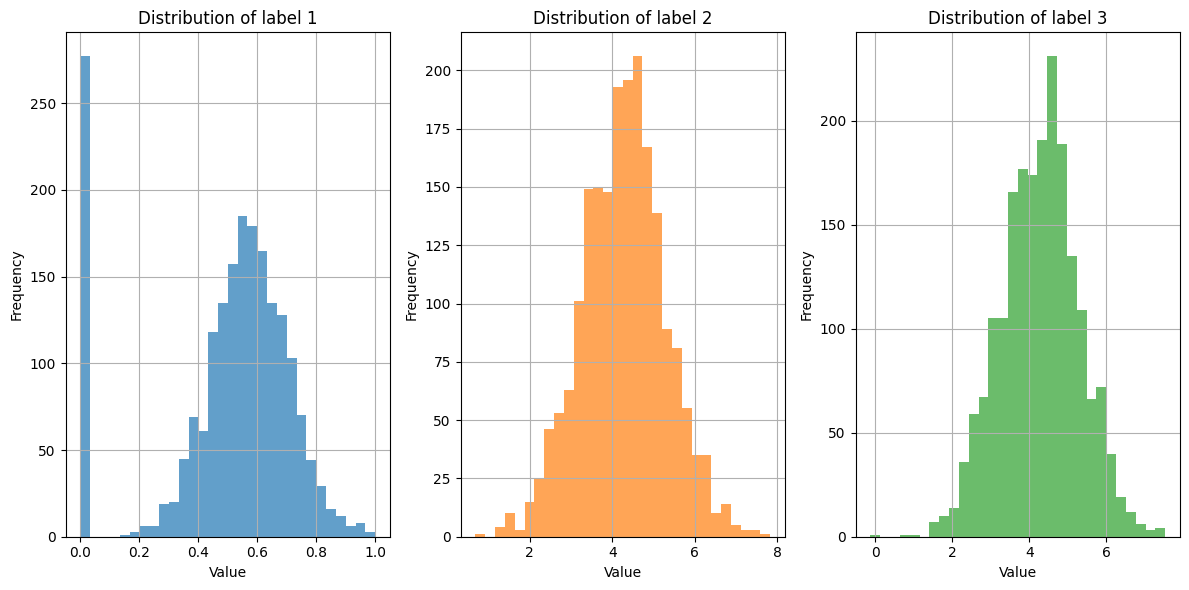

In [4]:
# Plot the label distributions in the same plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for j in range(n_targets):
    y_val = y[:, j]
    plt.subplot(1, n_targets, j + 1)
    plt.hist(y_val, bins=30, alpha=0.7, label=f'Label {j + 1}', color=f'C{j}')
    plt.title(f"Distribution of label {j + 1}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [308]:
import torch
from torch.utils.data import Dataset

class ToyRegressionDataset(Dataset):
    """
    PyTorch Dataset for the toy regression data.

    Args:
        X (np.ndarray): Feature matrix of shape (n_samples, n_features).
        y (np.ndarray): Target matrix of shape (n_samples, n_targets).
        feature_dims (dict): Dictionary mapping feature names to their dimensions.
    """
    def __init__(self, X, y, feature_dims, label_names=None):
        self.X = X
        self.y = y
        self.n_targets = y.shape[1] if y.ndim > 1 else 1
        self.feature_dims = feature_dims
        assert self.X.shape[1] == sum(feature_dims.values()), f"Feature dimensions do not match: {self.X.shape[1]} != {sum(feature_dims.values())}"
        self.label_names = label_names if label_names is not None else [f'label_{i}' for i in range(self.n_targets)]

        # Store feature names and their start/end indices
        self.feature_slices = {}
        start = 0
        for k, dim in self.feature_dims.items():
            end = start + dim
            self.feature_slices[k] = (start, end)
            start = end

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        item = {}
        for k, (start, end) in self.feature_slices.items():
            item[k] = self.X[idx, start:end]
        # Add labels for each target
        for j, label_name in enumerate(self.label_names):
            item[label_name] = self.y[idx, j] if self.n_targets > 1 else self.y[idx]
        # Add a dimension 1 in front of the concatenated labels
        item["labels"] = np.expand_dims(self.y[idx], axis=0) if self.n_targets > 1 else np.array([self.y[idx]])
        return item

feature_dims = {
    'feature_0': 256,
    'feature_1': 64,
    'feature_2': 64,
    'feature_3': 128,
}
toy_dataset = ToyRegressionDataset(X, y, feature_dims)
for k, v in toy_dataset[0].items():
    print(f"{k}: {v.shape} - {v.dtype}")
print()

from torch.utils.data import DataLoader
toy_dataloader = DataLoader(toy_dataset, batch_size=32, shuffle=True)
for batch in toy_dataloader:
    for k, v in batch.items():
        print(f"{k}: {v.shape} - {v.dtype}")
    break

feature_0: (256,) - float64
feature_1: (64,) - float64
feature_2: (64,) - float64
feature_3: (128,) - float64
label_0: () - float64
label_1: () - float64
label_2: () - float64
labels: (1, 3) - float64

feature_0: torch.Size([32, 256]) - torch.float64
feature_1: torch.Size([32, 64]) - torch.float64
feature_2: torch.Size([32, 64]) - torch.float64
feature_3: torch.Size([32, 128]) - torch.float64
label_0: torch.Size([32]) - torch.float64
label_1: torch.Size([32]) - torch.float64
label_2: torch.Size([32]) - torch.float64
labels: torch.Size([32, 1, 3]) - torch.float64


In [369]:
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Subset

class ToyRegressionDataModule(pl.LightningDataModule):
    def __init__(
        self,
        n_samples=2000,
        feature_dims={'feature_0': 256, 'feature_1': 64, 'feature_2': 64, 'feature_3': 128},
        label_names=None,
        n_targets=3,
        label_noise=0.1,
        random_state=42,
        batch_size=64,
        num_workers=0,
    ):
        super().__init__()
        self.n_samples = n_samples
        self.feature_dims = feature_dims
        self.n_targets = n_targets
        self.label_noise = label_noise
        self.random_state = random_state
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.label_names = label_names if label_names is not None else [f'label_{i}' for i in range(n_targets)]
        if self.n_targets > 0:
            self.zero_inflate_idx = rng.integers(0, self.n_targets)
            self.zero_inflated_label = self.label_names[zero_inflate_idx]

    def prepare_data(self):
        pass

    def setup(self, stage=None):
        rng = np.random.default_rng(self.random_state)
        # Use feature_dims dict to generate features
        features = [make_regression(n_samples=self.n_samples, n_features=dim, noise=0.1)[0] 
                    for dim in self.feature_dims.values()]
        X = np.hstack(features)
        y = rng.normal(loc=0, scale=1, size=(self.n_samples, self.n_targets))
        y += rng.uniform(-self.label_noise, self.label_noise, size=(self.n_samples, self.n_targets))
        min_label = np.min(y)
        if min_label < 0:
            y -= min_label + rng.uniform(0.1, 0.5)
        if self.n_targets > 0:
            zero_inflate_idx = self.zero_inflate_idx
            zero_fraction = rng.uniform(0.10, 0.15)
            num_zeros = int(self.n_samples * zero_fraction)
            zero_indices = rng.choice(self.n_samples, size=num_zeros, replace=False)
            y[zero_indices, zero_inflate_idx] = 0.0
            y[:, zero_inflate_idx] = (y[:, zero_inflate_idx] - np.min(y[:, zero_inflate_idx])) / (np.max(y[:, zero_inflate_idx]) - np.min(y[:, zero_inflate_idx]))

        # Randomly set 15% of the labels to NaN
        nan_fraction = 0.15
        num_nans = int(self.n_samples * nan_fraction)
        nan_indices = rng.choice(self.n_samples, size=num_nans, replace=False)
        y[nan_indices, rng.integers(0, self.n_targets, size=num_nans)] = np.nan

        # Convert X and y to numpy arrays
        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.float32)

        # Split indices
        indices = np.arange(self.n_samples)
        rng.shuffle(indices)
        train_end = int(0.7 * self.n_samples)
        val_end = int(0.9 * self.n_samples)
        self.train_indices = indices[:train_end]
        self.val_indices = indices[train_end:val_end]
        self.test_indices = indices[val_end:]
    
        # Create the datasets
        self.train_dataset = ToyRegressionDataset(
            X[self.train_indices],
            y[self.train_indices],
            self.feature_dims,
            self.label_names,
        )
        self.val_dataset = ToyRegressionDataset(
            X[self.val_indices],
            y[self.val_indices],
            self.feature_dims,
            self.label_names,
        )
        self.test_dataset = ToyRegressionDataset(
            X[self.test_indices],
            y[self.test_indices],
            self.feature_dims,
            self.label_names,
        )

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
        )


n_samples = 2000
feature_dims = {
    'feature_0': 256,
    'feature_1': 64,
    'feature_2': 64,
    'feature_3': 128,
}
n_targets = 3
label_noise = 0.1
random_state = 42

dm = ToyRegressionDataModule(
    n_samples=n_samples,
    feature_dims=feature_dims,
    n_targets=n_targets,
    label_noise=label_noise,
    random_state=random_state,
    batch_size=64,
    num_workers=0,
)

# Get a batch from the train dataloader
dm.setup()
train_loader = dm.test_dataloader()
for batch in train_loader:
    for k, v in batch.items():
        print(f"{k}: {v.shape} - {v.dtype}")
    print()
    # break

feature_0: torch.Size([64, 256]) - torch.float32
feature_1: torch.Size([64, 64]) - torch.float32
feature_2: torch.Size([64, 64]) - torch.float32
feature_3: torch.Size([64, 128]) - torch.float32
label_0: torch.Size([64]) - torch.float32
label_1: torch.Size([64]) - torch.float32
label_2: torch.Size([64]) - torch.float32
labels: torch.Size([64, 1, 3]) - torch.float32

feature_0: torch.Size([64, 256]) - torch.float32
feature_1: torch.Size([64, 64]) - torch.float32
feature_2: torch.Size([64, 64]) - torch.float32
feature_3: torch.Size([64, 128]) - torch.float32
label_0: torch.Size([64]) - torch.float32
label_1: torch.Size([64]) - torch.float32
label_2: torch.Size([64]) - torch.float32
labels: torch.Size([64, 1, 3]) - torch.float32

feature_0: torch.Size([64, 256]) - torch.float32
feature_1: torch.Size([64, 64]) - torch.float32
feature_2: torch.Size([64, 64]) - torch.float32
feature_3: torch.Size([64, 128]) - torch.float32
label_0: torch.Size([64]) - torch.float32
label_1: torch.Size([64]) - 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional

class GPTStyleFeedForward(nn.Module):
    """
    Pre-LN feed-forward block used in decoder-only Transformers (Radford et al., 2018/GPT family).

    Structure (for input X ∈ R^{BxTxd_model}):
        Y = X + Dropout( W2 * φ( W1 * LN(X) ) )
    where φ is GELU, and W1,W2 are linear (affine) maps with optional bias.

    Parameters
    ----------
    d_model : int
        Hidden size of the model.
    d_ff : Optional[int]
        Inner width of the MLP. Defaults to 4 * d_model if None.
    dropout : float
        Dropout probability applied after the second linear.
    bias : bool
        Whether to use bias terms in the two linear layers. In GPT-style models this is True. 
        (See HF GPT-2 `Conv1D` layers, which include `bias`.) 
    eps : float
        Epsilon for LayerNorm stability.

    Notes
    -----
    * This follows the *pre-norm* residual layout used in GPT-1/2: LayerNorm → MLP → residual add.
    * Activation is GELU, as in GPT-2.
    * Expected input shape is (batch, seq, d_model); the module is position-wise.
    """
    def __init__(
        self,
        d_model: int,
        d_ff: Optional[int] = None,
        dropout: float = 0.0,
        bias: bool = True,
        eps: float = 1e-5,
    ) -> None:
        super().__init__()
        inner = 4 * d_model if d_ff is None else d_ff

        # Pre-norm
        self.ln = nn.LayerNorm(d_model, eps=eps)

        # Two affine projections (bias enabled by default, matching GPT practice)
        self.fc1 = nn.Linear(d_model, inner, bias=bias)
        self.fc2 = nn.Linear(inner, d_model, bias=bias)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args
        ----
        x : Tensor of shape (B, T, d_model)

        Returns
        -------
        Tensor of shape (B, T, d_model)
        """
        # Pre-norm residual block
        h = self.ln(x)
        h = F.gelu(self.fc1(h))       # position-wise nonlinearity
        h = self.fc2(h)
        h = self.dropout(h)
        return x + h                   # residual add

class InputScaler(nn.Module):
    """
    Input scaling layer that applies a linear transformation to the input features.

    Parameters
    ----------
    in_features : int
        Number of input features.
    out_features : int
        Number of output features.
    bias : bool, optional
        Whether to include a bias term in the linear transformation. Default is True.
    norm : bool, optional
        Whether to apply Layer Normalization before the linear transformation. Default is False.
    """
    def __init__(
            self,
            in_features: int,
            out_features: int,
            bias: bool = True,
            norm: bool = False,
    ):
        super().__init__()
        self.norm = None
        if norm:
            self.norm = nn.LayerNorm(in_features)
        self.linear = nn.Linear(in_features, out_features, bias=bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.norm is not None:
            x = self.norm(x)
        x = self.linear(x)
        # Divide by the square root of the output dimension to maintain variance
        # This is a common practice in Transformer models to stabilize training
        return F.softmax(x / (self.linear.out_features ** 0.5), dim=-1)

In [371]:
from lightning_uq_box.viz_utils import (
    plot_calibration_uq_toolbox,
    plot_predictions_regression,
    plot_toy_regression_data,
    plot_training_metrics,
)
from lightning_uq_box.uq_methods.loss_functions import DERLoss
from lightning_uq_box.uq_methods.deep_evidential_regression import DERLayer

In [372]:
pl.seed_everything(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [384]:
from typing import List, Dict
from torch import nn
import torch

class Backbone(nn.Module):
    """
    Backbone network for feature embedding and trunk processing.
    """
    def __init__(
            self,
            feature_dims: Dict[str, int],
            hidden_dim: int = 128,
            trunk_size: int = 1,
            dropout: float = 0.1,
            norm: bool = False,
    ):
        super().__init__()
        self.input_embedding = nn.ModuleDict({
            k: InputScaler(d, hidden_dim, norm=norm) for k, d in feature_dims.items()
        })
        self.trunk = nn.Sequential(
            *[GPTStyleFeedForward(hidden_dim, hidden_dim, dropout) for _ in range(trunk_size)]
        )

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        embedded_features = [self.input_embedding[k](batch[k]) for k in self.input_embedding.keys()]
        x = torch.stack(embedded_features, dim=-1)  # (batch_size, hidden_dim, n_features)
        x = x.sum(dim=-1)  # (batch_size, hidden_dim)
        x = self.trunk(x)
        return x

class RegressionModel(nn.Module):
    """
    Regression model with backbone, linear head, and DER layer.
    """
    def __init__(
            self,
            feature_dims: Dict[str, int],
            n_targets: int = 1,
            trunk_size: int = 1,
            hidden_dim: int = 128,
            dropout: float = 0.1,
            norm: bool = False,
    ):
        super().__init__()
        self.backbone = Backbone(
            feature_dims=feature_dims,
            hidden_dim=hidden_dim,
            trunk_size=trunk_size,
            dropout=dropout,
            norm=norm,
        )
        self.lin_head = nn.Linear(hidden_dim, 4 * n_targets, bias=False)
        self.der_layer = DERLayer()

    def forward(self, batch: Dict[str, torch.Tensor], return_embeddings: bool = False) -> torch.Tensor:
        embedding = self.backbone(batch)
        x = self.lin_head(embedding)
        x = x.view(x.size(0), 4, -1)
        x = self.der_layer(x)
        if return_embeddings:
            return x, embedding
        return x

# Example usage
feature_dims = {
    'feature_0': 256,
    'feature_1': 64,
    'feature_2': 64,
    'feature_3': 128,
}
model = RegressionModel(
    feature_dims=feature_dims,
    n_targets=3,
    trunk_size=2,
    hidden_dim=128,
    dropout=0.1
)
# Print the model architecture
print(model)
# Example input batch
batch = {
    'feature_0': torch.randn(8, 256),
    'feature_1': torch.randn(8, 64),
    'feature_2': torch.randn(8, 64),
    'feature_3': torch.randn(8, 128),
}
# Forward pass
output = model(batch)
print("Output shape:", output.shape)  # Should be (8, 4, 3) for 8 samples, 4 outputs per target label
# Output shape: (8, 4, 3)

# Run it through a DER layer
print("DER output shape:", output.shape)  # Should be (8, 4, 3) for 8 samples, 4 outputs per target label
# Output shape: (8, 4, 3)

# Test with the DERLoss
der_loss = DERLoss(coeff=0.2)
loss = der_loss(output, torch.randn(8, 1, 3))
print("Loss:", loss.item())  # Should print a scalar loss value

RegressionModel(
  (backbone): Backbone(
    (input_embedding): ModuleDict(
      (feature_0): InputScaler(
        (linear): Linear(in_features=256, out_features=128, bias=True)
      )
      (feature_1): InputScaler(
        (linear): Linear(in_features=64, out_features=128, bias=True)
      )
      (feature_2): InputScaler(
        (linear): Linear(in_features=64, out_features=128, bias=True)
      )
      (feature_3): InputScaler(
        (linear): Linear(in_features=128, out_features=128, bias=True)
      )
    )
    (trunk): Sequential(
      (0): GPTStyleFeedForward(
        (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (fc1): Linear(in_features=128, out_features=128, bias=True)
        (fc2): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (1): GPTStyleFeedForward(
        (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (fc1): Linear(in_features=128, out_features=128, b

In [385]:
import tempfile

my_temp_dir = tempfile.mkdtemp()

In [393]:
from lightning.pytorch.loggers import CSVLogger
from lightning_uq_box.uq_methods.utils import default_regression_metrics

class DERModel(pl.LightningModule):

    def __init__(
            self,
            label_names: List[str] = None,
            label_weights: Dict[str, float] = None,
            der_loss_coeffs: Dict[str, float] = None,
            default_der_loss_coeff: float = 0.01,
            learning_rate: float = 1e-3,
            **model_kwargs: Dict[str, int],
    ):
        super().__init__()
        self.save_hyperparameters()

        self.learning_rate = learning_rate
        self.model = RegressionModel(**model_kwargs)

        self.label_names = label_names if label_names is not None else [f"label_{i}" for i in range(model_kwargs.get("n_targets", 1))]

        # Create explicit mapping from label names to output indices
        self.label_to_idx = {name: i for i, name in enumerate(self.label_names)}

        # Set up label weights - default to equal weights if not provided
        if label_weights is None:
            self.label_weights = {name: 1.0 for name in self.label_names}
        else:
            # Ensure all labels have weights, default missing ones to 1.0
            self.label_weights = {name: label_weights.get(name, 1.0) for name in self.label_names}
        
        # Normalize weights so they sum to the number of labels (maintains scale)
        total_weight = sum(self.label_weights.values())
        if total_weight > 0:
            self.label_weights = {name: weight * len(self.label_names) / total_weight 
                                 for name, weight in self.label_weights.items()}

        # Create individual DER loss functions for each label
        self.loss_functions = nn.ModuleDict()
        for label_name in self.label_names:
            coeff = der_loss_coeffs.get(label_name, default_der_loss_coeff) if der_loss_coeffs else default_der_loss_coeff
            self.loss_functions[label_name] = DERLoss(coeff)

        # Add metrics for logging
        self.metrics = {}
        for label in self.label_names:
            for stage in ["train", "val", "test"]:
                metric_id = f"{stage}_{label}"
                self.metrics[metric_id] = default_regression_metrics(f"{metric_id}_")
        # NOTE: Metrics are nn.Module, so they must be registered accordingly
        self.metrics = nn.ModuleDict(self.metrics)

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model(batch)

    def _prepare_labels_tensor(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        """
        Prepare labels tensor in the correct order for the loss function.
        
        Args:
            batch: Input batch containing labels
            
        Returns:
            torch.Tensor of shape (batch_size, 1, n_targets)
        """
        # Use self.label_to_idx to ensure correct ordering
        labels_list = [batch[label] for label in self.label_names]
        labels = torch.stack(labels_list, dim=-1)  # Shape: (batch_size, n_targets)
        return labels.unsqueeze(1)  # Shape: (batch_size, 1, n_targets)

    def _filter_nan_samples(self, preds: torch.Tensor, targets: torch.Tensor) -> tuple:
        """
        Filter out samples where targets contain NaN values.
        
        Args:
            preds: Predictions tensor
            targets: Target tensor
            
        Returns:
            Tuple of (filtered_preds, filtered_targets)
        """
        valid_mask = ~torch.isnan(targets)
        if valid_mask.sum() == 0:
            # If all samples are NaN, return empty tensors
            return preds[:0], targets[:0]
        
        return preds[valid_mask], targets[valid_mask]

    def _compute_weighted_loss(self, outputs: torch.Tensor, labels: torch.Tensor) -> tuple:
        """
        Compute weighted loss for each label and return the weighted average.
        
        Args:
            outputs: Model outputs of shape (batch_size, 4, n_targets)
            labels: Ground truth labels of shape (batch_size, 1, n_targets)
            
        Returns:
            Tuple of (weighted_loss, per_label_losses, valid_samples_per_label)
        """
        per_label_losses = []
        valid_samples_per_label = {}
        
        for label_name in self.label_names:
            idx = self.label_to_idx[label_name]
            
            # Extract outputs and labels for this specific label
            label_outputs = outputs[:, :, idx:idx+1]  # Shape: (batch_size, 4, 1)
            label_targets = labels[:, :, idx:idx+1]   # Shape: (batch_size, 1, 1)
            
            # Flatten for NaN filtering
            label_targets_flat = label_targets.squeeze(-1).squeeze(-1)  # Shape: (batch_size,)
            
            # Filter out NaN samples
            valid_mask = ~torch.isnan(label_targets_flat)
            n_valid = valid_mask.sum().item()
            valid_samples_per_label[label_name] = n_valid
            
            if n_valid == 0:
                # If all samples are NaN for this label, set loss to 0
                label_loss = torch.tensor(0.0, device=outputs.device, requires_grad=True)
                self.log(f"nan_warning_{label_name}", 1.0, on_step=False, on_epoch=True)
            else:
                # Filter valid samples
                valid_label_outputs = label_outputs[valid_mask]  # Shape: (n_valid, 4, 1)
                valid_label_targets = label_targets[valid_mask]  # Shape: (n_valid, 1, 1)
                
                # Compute loss for this label using its specific loss function
                label_loss = self.loss_functions[label_name](valid_label_outputs, valid_label_targets)
            
            per_label_losses.append(label_loss)
        
        # Stack losses and apply weights
        per_label_losses = torch.stack(per_label_losses)  # Shape: (n_targets,)
        
        # Apply weights - only to labels that have valid samples
        weighted_losses = []
        total_weight = 0.0
        
        for i, label_name in enumerate(self.label_names):
            if valid_samples_per_label[label_name] > 0:
                weight = self.label_weights[label_name]
                weighted_losses.append(per_label_losses[i] * weight)
                total_weight += weight
        
        if len(weighted_losses) == 0:
            # All labels have NaN - return zero loss
            weighted_loss = torch.tensor(0.0, device=outputs.device, requires_grad=True)
        else:
            # Compute weighted average
            weighted_loss = torch.stack(weighted_losses).sum() / max(total_weight, 1e-8)
        
        return weighted_loss, per_label_losses, valid_samples_per_label

    def _process_batch(self, batch: Dict[str, torch.Tensor], stage: str):
        """
        Helper method to process a batch for training, validation, or testing.
        Reduces code duplication and ensures consistent logic.
        """
        outputs = self(batch)
        labels = self._prepare_labels_tensor(batch)
        
        # Compute weighted loss and per-label losses
        loss, per_label_losses, valid_samples_count = self._compute_weighted_loss(outputs, labels)
        
        # Log overall loss
        self.log(f"{stage}_loss", loss, on_step=(stage=="train"), on_epoch=True, prog_bar=True)
        
        # Log per-label losses and valid sample counts
        for i, label_name in enumerate(self.label_names):
            self.log(f"{stage}_loss_{label_name}", per_label_losses[i], 
                    on_step=(stage=="train"), on_epoch=True, prog_bar=False)
            self.log(f"{stage}_valid_samples_{label_name}", valid_samples_count[label_name], 
                    on_step=False, on_epoch=True, prog_bar=False)

        # Update metrics for each label using explicit mapping (with NaN filtering)
        for label_name, output_idx in self.label_to_idx.items():
            preds = outputs[:, 0, output_idx]  # Get predictions for this label
            target = batch[label_name]  # Get target for this label
            
            # Filter out NaN values for metrics computation
            filtered_preds, filtered_target = self._filter_nan_samples(preds, target)
            
            if len(filtered_target) > 0:  # Only compute metrics if we have valid samples
                metrics_key = f"{stage}_{label_name}"
                if stage == "train":
                    # For training, compute and log metrics immediately
                    scores = self.metrics[metrics_key](filtered_preds, filtered_target)
                    self.log_dict(scores)
                else:
                    # For validation/test, just update metrics
                    self.metrics[metrics_key].update(filtered_preds, filtered_target)
        
        return loss

    def training_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        return self._process_batch(batch, "train")

    def validation_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        return self._process_batch(batch, "val")

    def on_validation_epoch_end(self):
        for label_name in self.label_names:
            metrics_key = f"val_{label_name}"
            metrics = self.metrics[metrics_key].compute()
            self.log_dict(metrics)
            self.metrics[metrics_key].reset()

    def test_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        return self._process_batch(batch, "test")

    def on_test_epoch_end(self):
        for label_name in self.label_names:
            metrics_key = f"test_{label_name}"
            metrics = self.metrics[metrics_key].compute()
            self.log_dict(metrics)
            self.metrics[metrics_key].reset()

    def predict_step(
        self, X: torch.Tensor, batch_idx: int = 0, dataloader_idx: int = 0
    ) -> Dict[str, torch.Tensor]:
        """Prediction Step Deep Evidential Regression.

        Args:
            X: prediction batch of shape [batch_size x input_dims]
            batch_idx: the index of this batch
            dataloader_idx: the index of the dataloader

        Returns:
            dictionary with predictions and uncertainty measures
        """
        with torch.no_grad():
            pred = self.forward(X)  # [batch_size x 4 x othe_dims]

        gamma, nu, alpha, beta = (
            pred[:, 0:1, ...],
            pred[:, 1:2, ...],
            pred[:, 2:3, ...],
            pred[:, 3:4, ...],
        )

        epistemic_uct = self.compute_epistemic_uct(nu)
        aleatoric_uct = self.compute_aleatoric_uct(beta, alpha, nu)
        pred_uct = epistemic_uct + aleatoric_uct

        results = {
            "pred": gamma.squeeze(1),
            "pred_uct": pred_uct.squeeze(1),
            "aleatoric_uct": aleatoric_uct.squeeze(1),
            "epistemic_uct": epistemic_uct.squeeze(1),
            "out": pred,
        }
    
        for label_name, idx in self.label_to_idx.items():
            results[f"pred_{label_name}"] = gamma[:, 0, idx]
            results[f"pred_uct_{label_name}"] = pred_uct[:, 0, idx]
            results[f"aleatoric_uct_{label_name}"] = aleatoric_uct[:, 0, idx]
            results[f"epistemic_uct_{label_name}"] = epistemic_uct[:, 0, idx]

        return results

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.learning_rate)

    def compute_aleatoric_uct(self, beta: torch.Tensor, alpha: torch.Tensor, nu: torch.Tensor) -> torch.Tensor:
        """Compute the aleatoric uncertainty for DER model.

        Equation 10 of the paper

        Args:
            beta: beta output DER model
            alpha: alpha output DER model
            nu: nu output DER model

        Returns:
            Aleatoric Uncertainty
        """
        return torch.sqrt(torch.div(beta * (1 + nu), alpha * nu))

    def compute_epistemic_uct(self, nu: torch.Tensor) -> torch.Tensor:
        """Compute the aleatoric uncertainty for DER model.

        Equation 10: of the paper

        Args:
            nu: nu output DER model
        Returns:
            Epistemic Uncertainty
        """
        return torch.reciprocal(torch.sqrt(nu))
    
    def extract_embeddings(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        """
        Extract embeddings from the model for the given batch.
        
        Args:
            batch: Input batch containing features
            
        Returns:
            Tensor of shape (batch_size, hidden_dim)
        """
        with torch.no_grad():
            _, embeddings = self.model.eval()(batch, return_embeddings=True)
        return embeddings

n_samples = 6_000
n_targets = 3
label_noise = 0.1
batch_size = 64
trunk_size = 1
hidden_dim = 256
dropout = 0.7
feature_dims = {
    "molecule": 256,
    "e3": 64,
    "poi": 64,
    "cell": 128,
}
label_names = ["Dmax", "pDC50", "pIC50"]

# Define custom weights for each label
label_weights = {
    "Dmax": 2.0,    # Higher importance
    "pDC50": 1.5,   # Medium importance  
    "pIC50": 1.0    # Standard importance
}

# Define different DER loss coefficients for each label
der_loss_coeffs = {
    "Dmax": 0.1,    # Lower regularization
    "pDC50": 0.2,   # Medium regularization
    "pIC50": 0.3    # Higher regularization
}

dm = ToyRegressionDataModule(
    n_samples=n_samples,
    feature_dims=feature_dims,
    n_targets=n_targets,
    label_names=label_names,
    label_noise=label_noise,
    random_state=random_state,
    batch_size=batch_size,
    num_workers=0,
)

zero_inflated_label = dm.zero_inflated_label
label_weights[zero_inflated_label] = 1.0
der_loss_coeffs[zero_inflated_label] = 0.3

print(f"Zero-inflated label: {zero_inflated_label}")

der_model = DERModel(
    label_names=label_names,
    label_weights=label_weights,
    der_loss_coeffs=der_loss_coeffs,
    feature_dims=feature_dims,
    n_targets=n_targets,
    trunk_size=trunk_size,
    hidden_dim=hidden_dim,
    dropout=dropout,
    learning_rate=1e-4,
)
print(der_model)

# # Get a batch from the dataloader
# dm.setup()
# batch = next(iter(dm.train_dataloader()))
# for k, v in batch.items():
#     print(f"{k}: {v.shape} - {v.dtype}")

# # Run a prediction step
# predictions = der_model.predict_step(batch)
# for k, v in predictions.items():
#     print(f"{k}: {v.shape} - {v.dtype}")

# der_model.training_step(batch, 0)  # Run a training step to test the model

Zero-inflated label: Dmax
DERModel(
  (model): RegressionModel(
    (backbone): Backbone(
      (input_embedding): ModuleDict(
        (molecule): InputScaler(
          (linear): Linear(in_features=256, out_features=256, bias=True)
        )
        (e3): InputScaler(
          (linear): Linear(in_features=64, out_features=256, bias=True)
        )
        (poi): InputScaler(
          (linear): Linear(in_features=64, out_features=256, bias=True)
        )
        (cell): InputScaler(
          (linear): Linear(in_features=128, out_features=256, bias=True)
        )
      )
      (trunk): Sequential(
        (0): GPTStyleFeedForward(
          (ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear(in_features=256, out_features=256, bias=True)
          (fc2): Linear(in_features=256, out_features=256, bias=True)
          (dropout): Dropout(p=0.7, inplace=False)
        )
      )
    )
    (lin_head): Linear(in_features=256, out_features=12, bias=False)
   

In [406]:
dm.setup()
batch = next(iter(dm.train_dataloader()))
extracted_embeddings = der_model.extract_embeddings(batch)
print("Extracted embeddings shape:", extracted_embeddings.shape, extracted_embeddings.mean())  # Should be (batch_size, hidden_dim)

Extracted embeddings shape: torch.Size([64, 256]) tensor(0.0152)


In [415]:
extracted_embeddings = der_model.extract_embeddings(batch)
print("Extracted embeddings shape:", extracted_embeddings.shape, extracted_embeddings.mean())  # Should be (batch_size, hidden_dim)

Extracted embeddings shape: torch.Size([64, 256]) tensor(0.0152)


In [389]:
logger = CSVLogger(my_temp_dir)
trainer = pl.Trainer(
    max_epochs=2,  # number of epochs we want to train
    logger=logger,  # log training metrics for later evaluation
    log_every_n_steps=1,
    enable_checkpointing=False,
    enable_progress_bar=True,
    default_root_dir=my_temp_dir,
    # fast_dev_run=True,
    num_sanity_val_steps=1, # Run one validation step before training to check the model and data
    val_check_interval=0.5,  # Validate every 50% of the training steps
    gradient_clip_val=1.0,  # Clip gradients to avoid exploding gradients
)
trainer.fit(der_model, datamodule=dm)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name           | Type            | Params | Mode 
-----------------------------------------------------------
0 | model          | RegressionModel | 267 K  | train
1 | loss_functions | ModuleDict      | 0      | train
2 | metrics        | ModuleDict      | 0      | train
-----------------------------------------------------------
267 K     Trainable params
0         Non-trainable params
267 K     Total params
1.069     Total estimated model params size (MB)
60        Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


Epoch 1: 100%|██████████| 66/66 [00:04<00:00, 13.23it/s, v_num=1, train_loss_step=2.280, val_loss=2.120, train_loss_epoch=4.990]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 66/66 [00:05<00:00, 13.20it/s, v_num=1, train_loss_step=2.280, val_loss=2.120, train_loss_epoch=4.990]


--------------------
Plotting train metrics
--------------------
Label 1: Dmax


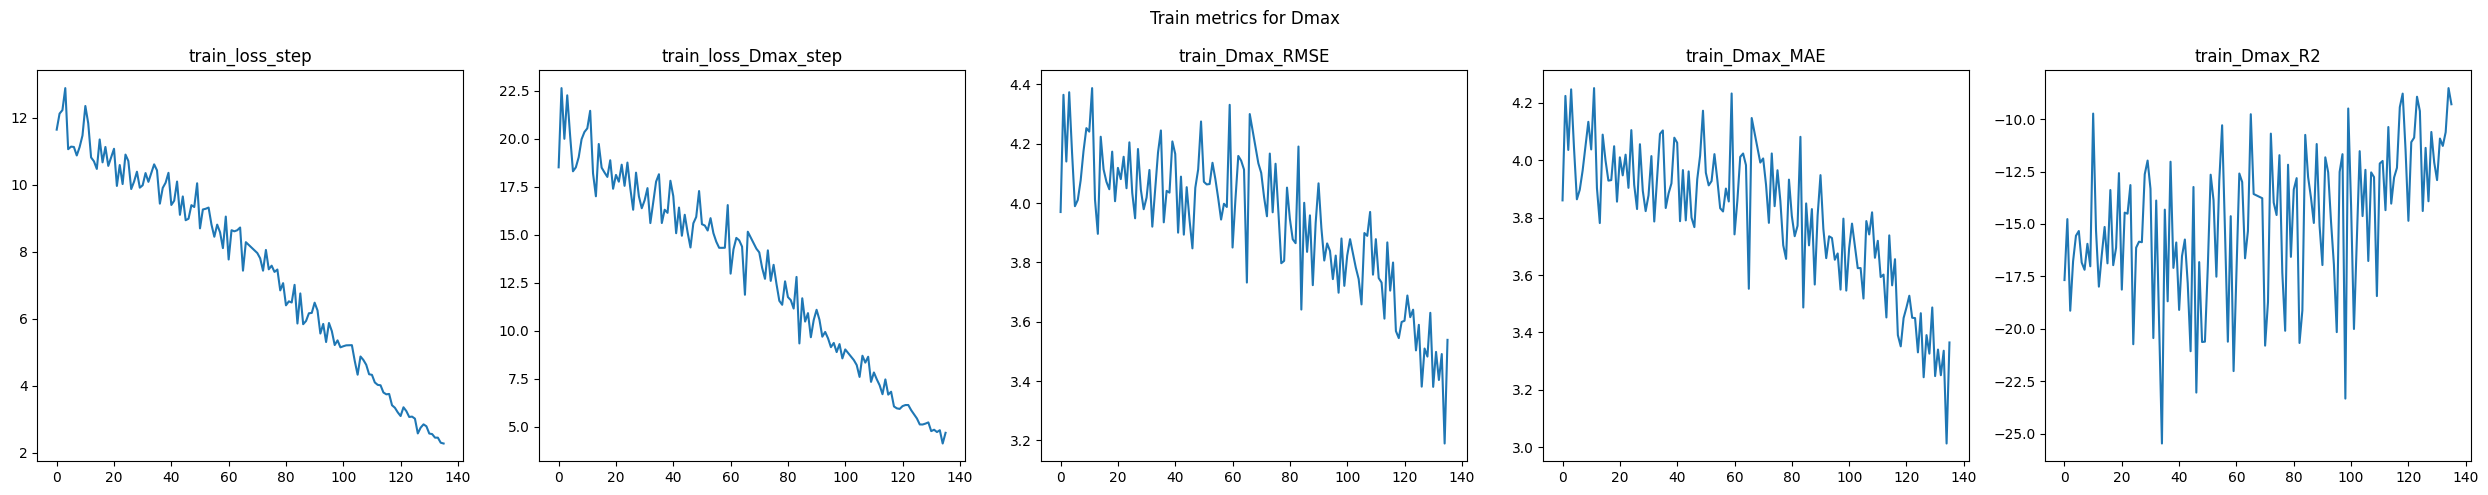

Label 2: pDC50


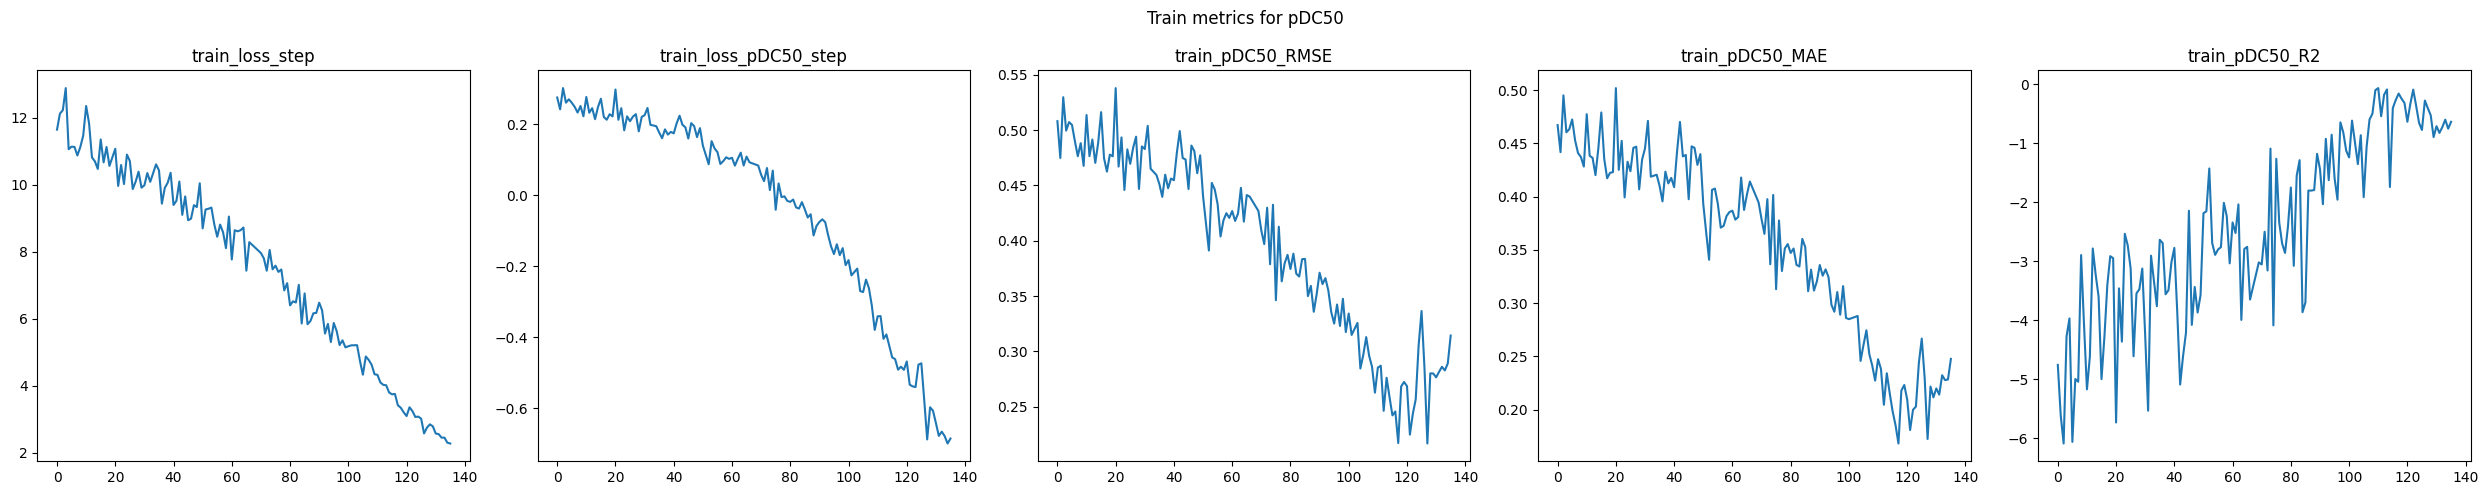

Label 3: pIC50


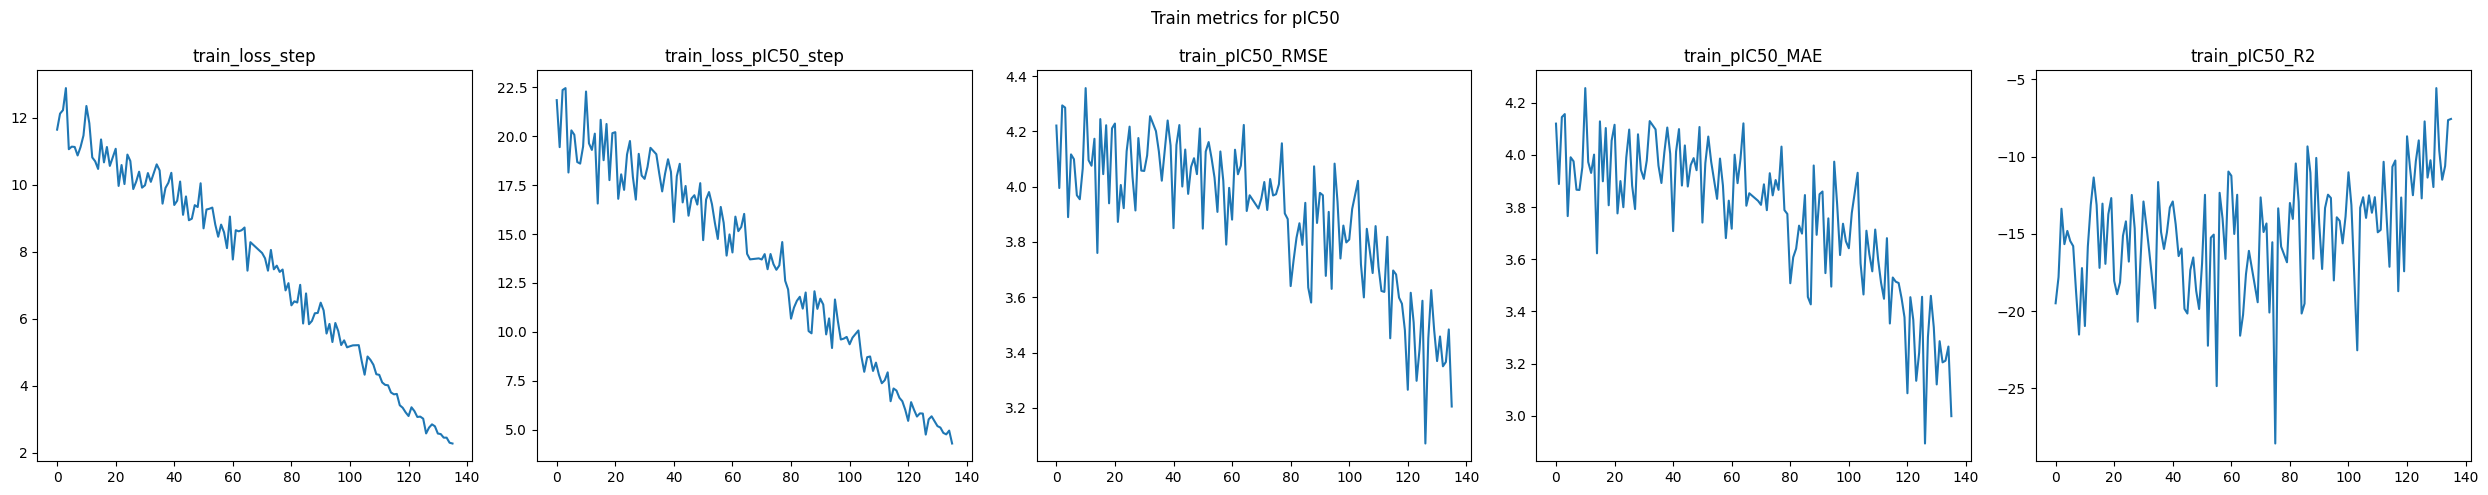

--------------------
Plotting val metrics
--------------------
Label 1: Dmax


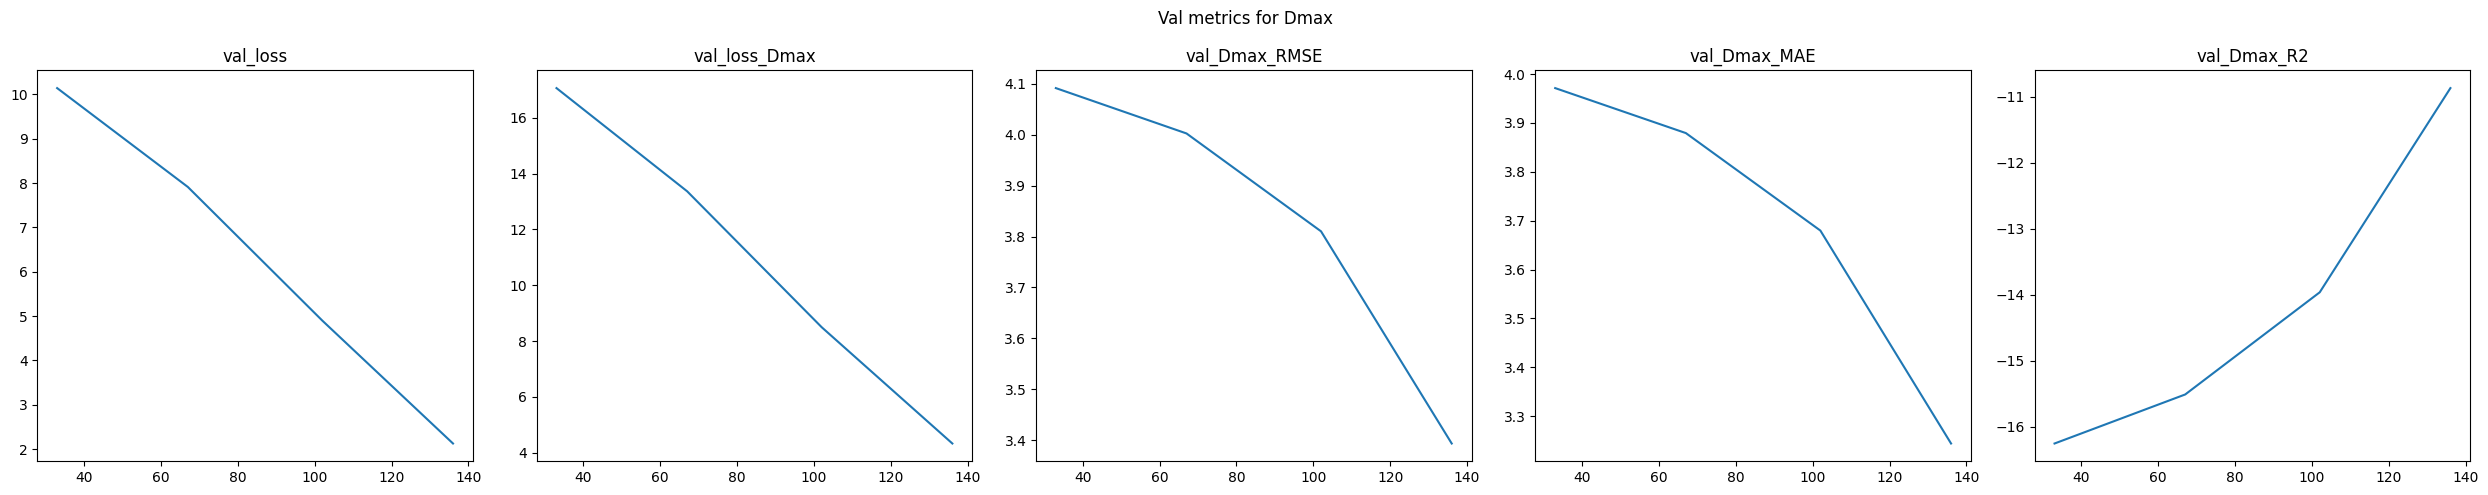

Label 2: pDC50


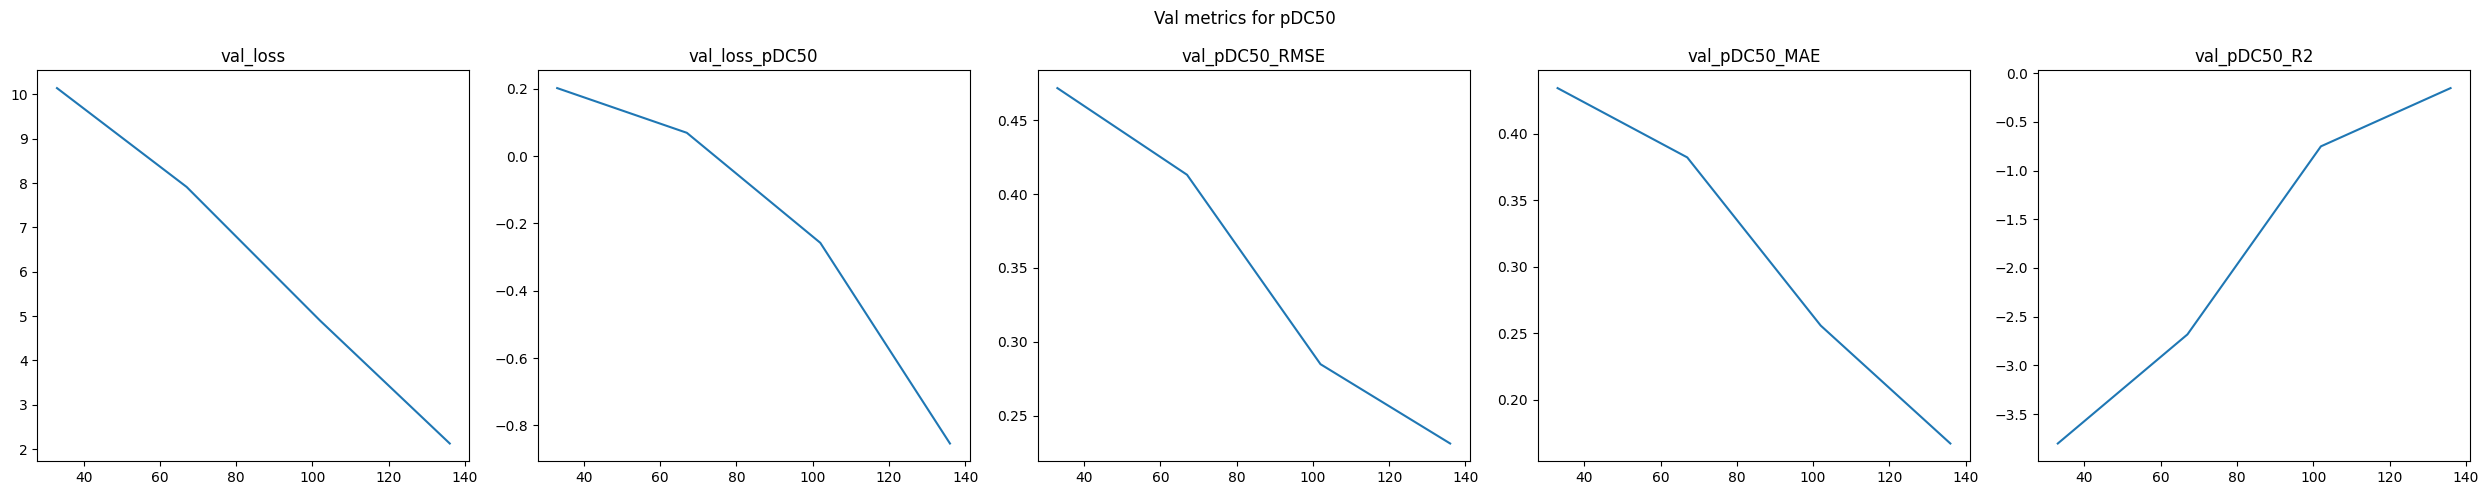

Label 3: pIC50


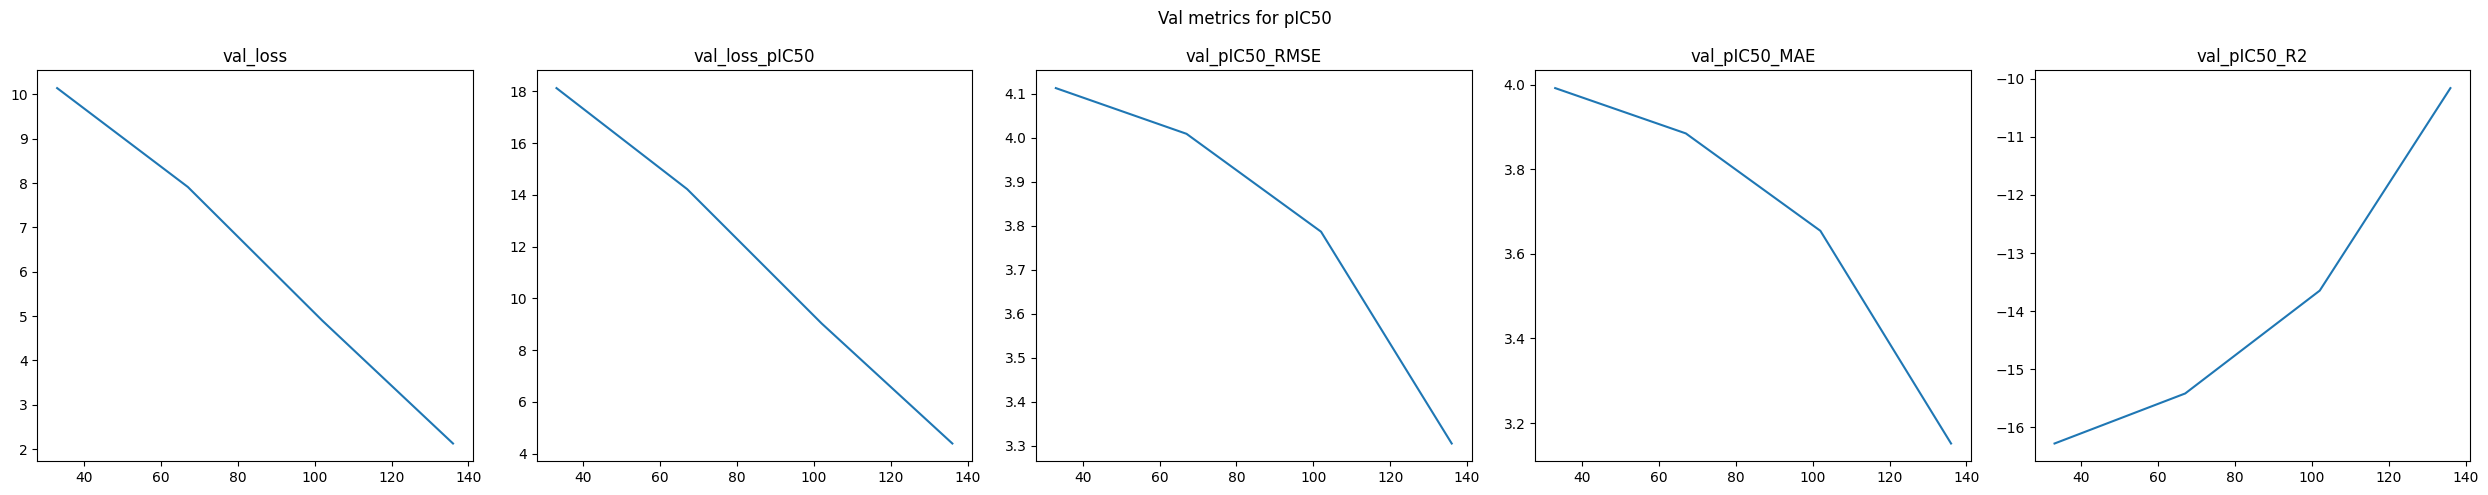

In [390]:
import os

for stage in ["train", "val"]:
    print("-" * 20)
    print(f"Plotting {stage} metrics")
    print("-" * 20)
    for i, label_name in enumerate(label_names):
        print(f"Label {i + 1}: {label_name}")
        metrics_to_plot = [
            f"{stage}_loss" + ("_step" if stage == "train" else ""),
            f"{stage}_loss_{label_name}" + ("_step" if stage == "train" else ""),
            f"{stage}_{label_name}_RMSE",
            f"{stage}_{label_name}_MAE",
            f"{stage}_{label_name}_R2",
        ]
        fig = plot_training_metrics(
            os.path.join(my_temp_dir,"lightning_logs"), metrics_to_plot,
        )
        # Plot fig
        fig.suptitle(f"{stage.title()} metrics for {label_name}")
        plt.tight_layout()
        plt.show()

/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 111.63it/s]
pred: torch.Size([64, 3]) - torch.float32
pred_uct: torch.Size([64, 3]) - torch.float32
aleatoric_uct: torch.Size([64, 3]) - torch.float32
epistemic_uct: torch.Size([64, 3]) - torch.float32
out: torch.Size([64, 4, 3]) - torch.float32
pred_Dmax: torch.Size([64]) - torch.float32
pred_uct_Dmax: torch.Size([64]) - torch.float32
aleatoric_uct_Dmax: torch.Size([64]) - torch.float32
epistemic_uct_Dmax: torch.Size([64]) - torch.float32
pred_pDC50: torch.Size([64]) - torch.float32
pred_uct_pDC50: torch.Size([64]) - torch.float32
aleatoric_uct_pDC50: torch.Size([64]) - torch.float32
epistemic_uct_pDC50: torch.Size([64]) - torch.float32
pred_pIC50: torch.Size([64]) - torch.float32
pred_uct_pIC50: torch.Size([64]) - torch.float32
aleatoric_uct_pIC50: torch.Size([64]) - torch.float32
epistemic_uct_pIC50: torch.Size([64]) - torch.float32

Predictions shape: torch.Size([64, 3])
Stacked predictions shape: torch.Size([600, 3])
La

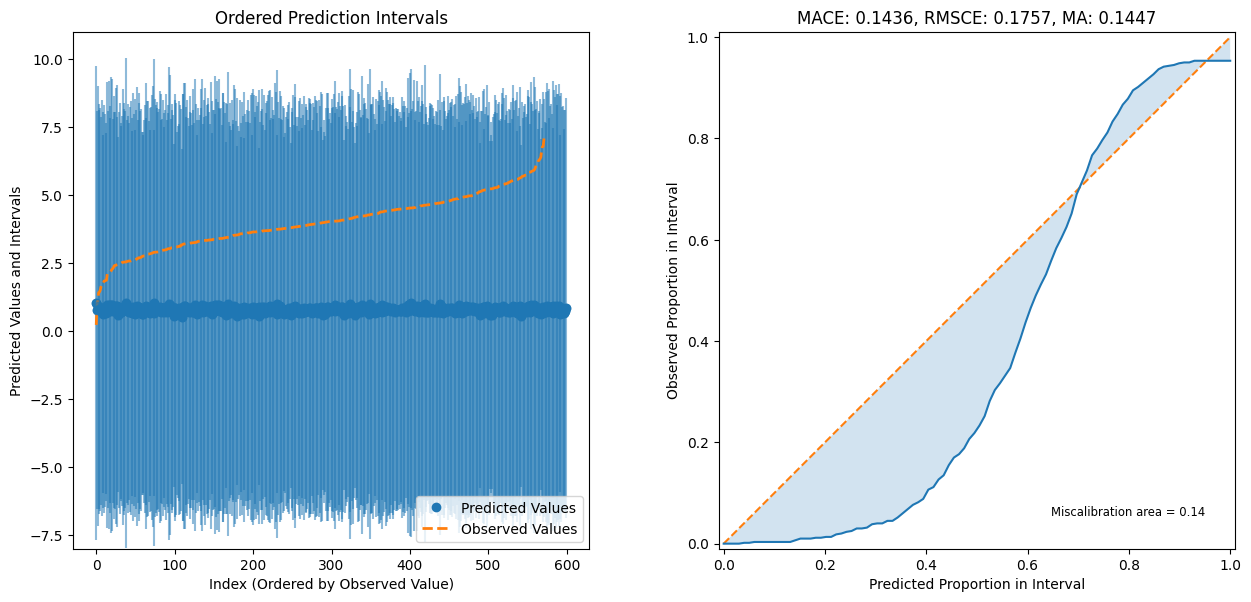

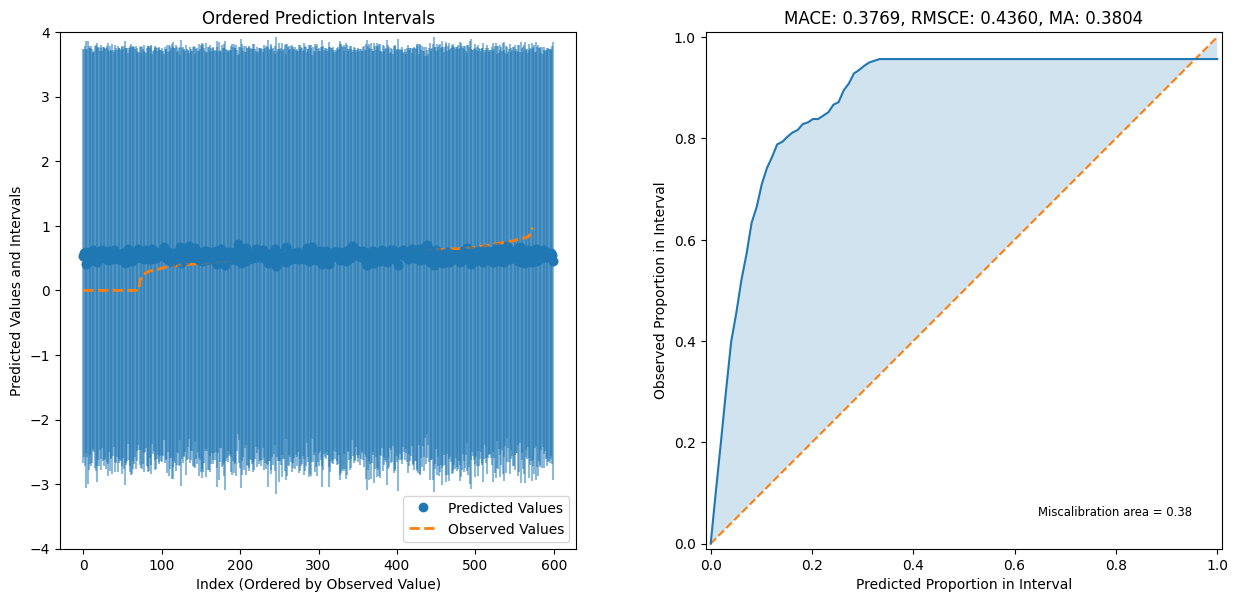

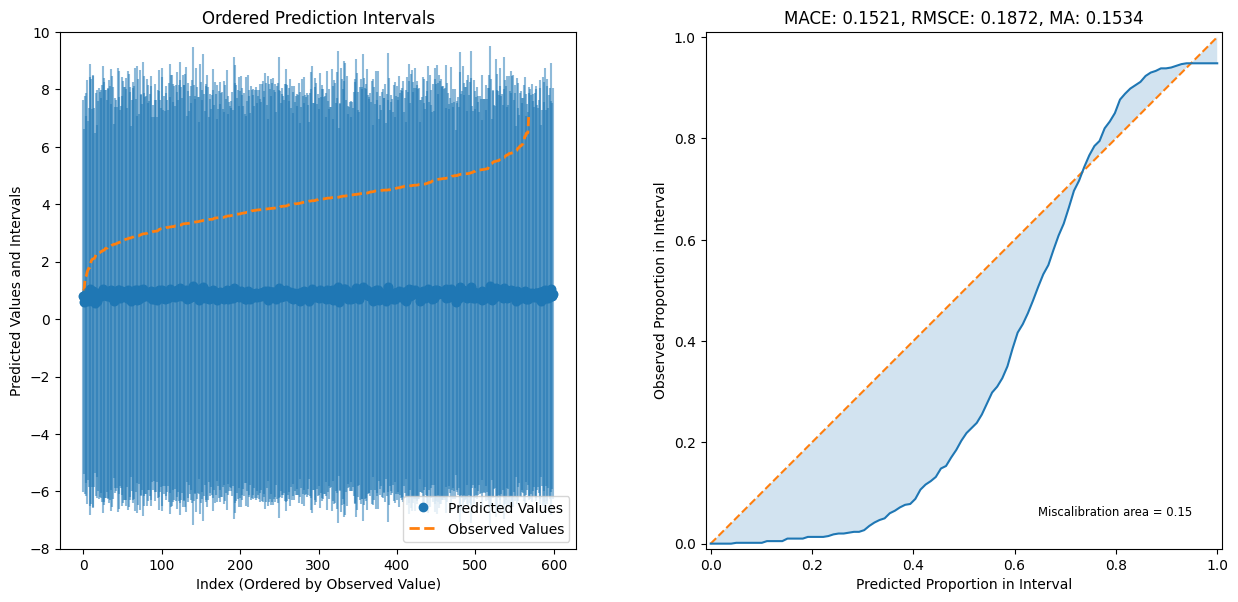

In [391]:
import uncertainty_toolbox as uct

def plot_predictions_regression(
        y_pred: np.ndarray,
        pred_std: np.ndarray,
        Y_test: np.ndarray,
        x_test: Optional[np.ndarray] = None,
        skip_xy_plot: bool = True,
) -> plt.Figure:
    """Plot calibration from uq_toolbox.

    Taken from https://github.com/uncertainty-toolbox/uncertainty-toolbox/
    blob/main/examples/viz_readme_figures.py.

    Args:
      y_pred: model mean predictions
      pred_std: predicted standard deviations
      Y_test: test data targets
      x_test: test data inputs
    """
    y_pred = y_pred.squeeze()
    pred_std = pred_std.squeeze()
    Y_test = Y_test.squeeze()
    if x_test is not None:
        x_test = x_test.squeeze()
    # n_subset = min(50, y_pred.shape[0])
    n_subset = y_pred.shape[0]
    mace = uct.mean_absolute_calibration_error(y_pred, pred_std, Y_test)
    ma = uct.miscalibration_area(y_pred, pred_std, Y_test)
    rmsce = uct.root_mean_squared_calibration_error(y_pred, pred_std, Y_test)

    if skip_xy_plot:
        fig, axs = plt.subplots(1, 2, figsize=(15, 8))

        # Make ordered intervals plot
        axs[0] = uct.plot_intervals_ordered(
            y_pred, pred_std, Y_test, n_subset=n_subset, ax=axs[0]
        )

        # Make calibration plot
        axs[1] = uct.plot_calibration(y_pred, pred_std, Y_test, ax=axs[1])

        # Adjust subplots spacing
        fig.subplots_adjust(wspace=0.25)

        axs[1].set_title(f"MACE: {mace:.4f}, RMSCE: {rmsce:.4f}, MA: {ma:.4f}")

        return fig
    else:
        fig, axs = plt.subplots(1, 3)

        # Make xy plot
        axs[0] = uct.plot_xy(y_pred, pred_std, Y_test, x_test, ax=axs[0])

        # Make ordered intervals plot
        axs[1] = uct.plot_intervals_ordered(
            y_pred, pred_std, Y_test, n_subset=n_subset, ax=axs[1]
        )

        # Make calibration plot
        axs[2] = uct.plot_calibration(y_pred, pred_std, Y_test, ax=axs[2])

        # Adjust subplots spacing
        fig.subplots_adjust(wspace=0.25)

        axs[2].set_title(f"MACE: {mace:.4f}, RMSCE: {rmsce:.4f}, MA: {ma:.4f}")

        return fig

# batch = next(iter(dm.test_dataloader()))
# preds = der_model.predict_step(batch)
preds = trainer.predict(der_model, dataloaders=dm.test_dataloader())
for k, v in preds[0].items():
    print(f"{k}: {v.shape} - {v.dtype}")
print()
# Stack predictions from all batches
print(f"Predictions shape: {preds[0]['pred'].shape}")  # Should be (batch_size, n_targets)
preds = {k: torch.cat([p[k] for p in preds], dim=0) for k in preds[0].keys()}
print(f"Stacked predictions shape: {preds['pred'].shape}")  # Should be (n_samples, n_targets)

# Assemble the labels from the batches in the test dataloader
labels = {}
for batch in dm.test_dataloader():
    for i, label_name in enumerate(label_names):
        if label_name not in labels:
            labels[label_name] = batch[label_name]
        else:
            labels[label_name] = torch.cat((labels[label_name], batch[label_name]), dim=0)
print(f"Labels shape: {labels[label_names[0]].shape}")  # Should be (n_samples,)

for i, label_name in enumerate(label_names):
    fig = plot_predictions_regression(
        y_pred=preds[f"pred_{label_name}"].cpu().numpy(),
        pred_std=preds[f"pred_uct_{label_name}"].cpu().numpy(),
        Y_test=labels[label_name].cpu().numpy(),
        x_test=None,
    )

In [392]:
metrics = trainer.test(der_model, dataloaders=dm.test_dataloader())

/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 34.27it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_Dmax_MAE          3.205122232437134
      test_Dmax_R2          -10.079704284667969
     test_Dmax_RMSE         3.3585102558135986
        test_loss           2.1230251789093018
     test_loss_Dmax          4.259124755859375
     test_loss_pDC50        -0.8430148363113403
     test_loss_pIC50         4.435985088348389
     test_pDC50_MAE         0.16307994723320007
      test_pDC50_R2        -0.17824208736419678
     test_pDC50_RMSE        0.23487259447574615
     test_pIC50_MAE         3.1736626625061035
      test_pIC50_R2         -10.550127029418945
     test_pIC50_RMSE        3.3219001293182373
 test_valid_samples_Dmax   

In [ ]:
der_model.